<a href="https://colab.research.google.com/github/Hamza9238/transformer-nlp-assignment/blob/main/Assignment4_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer NLP Assignment
## BERT Fine-Tuning + Attention Analysis + SHAP + LIME + Error Analysis
**Dataset:** [Amazon Polarity](https://huggingface.co/datasets/fancyzhx/amazon_polarity)  
**Model:** `bert-base-uncased` (fine-tuned for binary sentiment classification)

---
### Table of Contents
1. [Install Dependencies](#1-install-dependencies)
2. [Imports & Environment Setup](#2-imports--environment-setup)
3. [Dataset Loading & Preparation](#3-dataset-loading--preparation)
4. [Tokenization](#4-tokenization)
5. [Model Definition & Training](#5-model-definition--training)
6. [Evaluation & Classification Metrics](#6-evaluation--classification-metrics)
7. [Attention Analysis](#7-attention-analysis)
8. [SHAP Explainability](#8-shap-explainability)
9. [LIME Explainability](#9-lime-explainability)
10. [Comparative Analysis: SHAP vs LIME](#10-comparative-analysis-shap-vs-lime)
11. [Error Analysis](#11-error-analysis)


## 1. Install Dependencies

In [1]:
# Run once — restart kernel after installation if needed
import sys
!{sys.executable} -m pip install -q \
    torch torchvision \
    transformers datasets accelerate \
    shap lime \
    scikit-learn matplotlib seaborn tqdm sentencepiece
print("Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installation complete.


## 2. Imports & Environment Setup

In [2]:
import os, random, csv, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# HuggingFace
from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# Explainability
import shap
from lime.lime_text import LimeTextExplainer

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 3. Dataset Loading & Preparation
Loading the **Amazon Polarity** dataset from HuggingFace Hub.  
A practical subset is used so the notebook runs on standard hardware.


In [3]:
print("Loading Amazon Polarity dataset...")
dataset = load_dataset("fancyzhx/amazon_polarity")

TRAIN_SIZE = 2000   # Adjust based on your hardware (reduce to 2000 for quick test)
VAL_SIZE   = 200
TEST_SIZE  = 200

train_data = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_full  = dataset["test"].shuffle(seed=SEED)
val_data   = test_full.select(range(VAL_SIZE))
test_data  = test_full.select(range(VAL_SIZE, VAL_SIZE + TEST_SIZE))

print(f"Train : {len(train_data):,}")
print(f"Val   : {len(val_data):,}")
print(f"Test  : {len(test_data):,}")
print(f"Label split (train): {train_data['label'].count(0):,} NEG / {train_data['label'].count(1):,} POS")

Loading Amazon Polarity dataset...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Train : 2,000
Val   : 200
Test  : 200
Label split (train): 1,011 NEG / 989 POS


## 4. Tokenization
`BertTokenizerFast` with **WordPiece** tokenization.  
Title and content are concatenated with a `[SEP]` delimiter; sequences are truncated to 128 tokens.


In [4]:
MODEL_NAME = "bert-base-uncased"
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    texts = [t + " [SEP] " + c for t, c in zip(batch["title"], batch["content"])]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

print("Tokenizing splits...")
train_data = train_data.map(tokenize_fn, batched=True, batch_size=1000)
val_data   = val_data.map(tokenize_fn,   batched=True, batch_size=1000)
test_data  = test_data.map(tokenize_fn,  batched=True, batch_size=1000)

train_data = train_data.rename_column("label", "labels")
val_data = val_data.rename_column("label", "labels")
test_data = test_data.rename_column("label", "labels")

for split in [train_data, val_data, test_data]:
    split.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])
print("Tokenization complete.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing splits...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenization complete.


## 5. Model Definition & Training
Fine-tuning **bert-base-uncased** (12-layer, 768-dim, 12-head, 110M params) for binary classification.  
Training for **3 epochs** with AdamW, lr=2e-5, warmup=500 steps.


In [5]:
print("Loading BERT model...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)
model.to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 109,483,778


In [6]:
def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    preds  = logits.argmax(-1)
    acc    = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

os.makedirs("./results/checkpoints", exist_ok=True)

training_args = TrainingArguments(
    output_dir="./results/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./results/logs",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

os.makedirs("./results/bert_amazon_polarity", exist_ok=True)
model.save_pretrained("./results/bert_amazon_polarity")
tokenizer.save_pretrained("./results/bert_amazon_polarity")
print("Model saved to ./results/bert_amazon_polarity")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.677065,0.553282,0.750000,0.669065,0.958763,0.788136
2,0.441833,0.220515,0.920000,0.871560,0.979381,0.922330
3,0.219169,0.173598,0.940000,0.947368,0.927835,0.937500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./results/bert_amazon_polarity


In [7]:
# Save model and tokenizer to local PC
model.save_pretrained("./results/bert_amazon_polarity")
tokenizer.save_pretrained("./results/bert_amazon_polarity")
print("Model and tokenizer saved!")

# Download as zip
import shutil
from google.colab import files

shutil.make_archive("bert_amazon_polarity", "zip", "./results/bert_amazon_polarity")
files.download("bert_amazon_polarity.zip")
print("Download started!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


## 6. Evaluation & Classification Metrics
Reporting **Accuracy, Precision, Recall, and F1-score** on the held-out test set.


In [8]:
print("Evaluating on test set...")
preds_output = trainer.predict(test_data)
logits = preds_output.predictions[0] if isinstance(preds_output.predictions, tuple) else preds_output.predictions
y_pred = logits.argmax(-1)
y_true = preds_output.label_ids

report = classification_report(y_true, y_pred, target_names=["NEGATIVE", "POSITIVE"])
print("\n--- Classification Report ---")
print(report)

os.makedirs("./results", exist_ok=True)
with open("./results/classification_report.txt", "w") as f:
    f.write(report)
    f.write(f"\nEvaluated on {len(y_true)} samples.\nTimestamp: {datetime.now()}\n")

Evaluating on test set...



--- Classification Report ---
              precision    recall  f1-score   support

    NEGATIVE       0.91      0.97      0.94        94
    POSITIVE       0.97      0.92      0.94       106

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



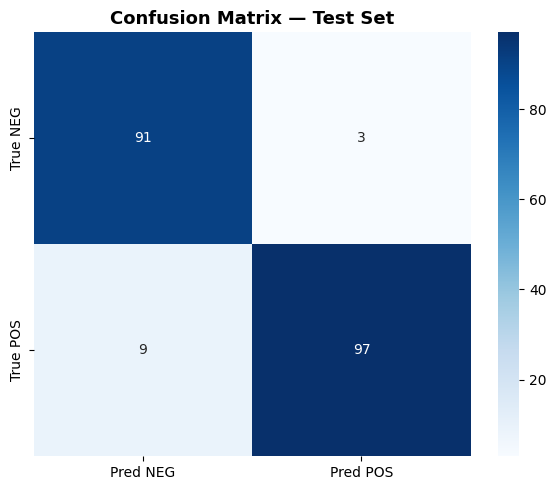

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred NEG", "Pred POS"],
            yticklabels=["True NEG", "True POS"], ax=ax)
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("./results", exist_ok=True)
plt.savefig("./results/confusion_matrix.png", dpi=150)
plt.show()

## 7. Attention Analysis
Extracting and visualizing attention maps from **layers 1, 6, and 12** across multiple heads.  
Lower entropy = more focused attention (more selective token relationships).


In [10]:
# ── Load saved model for attention extraction ──────────────────────
MODEL_PATH = "./results/bert_amazon_polarity"
attn_model = BertForSequenceClassification.from_pretrained(MODEL_PATH, output_attentions=True)
attn_model.to(DEVICE)
attn_model.eval()
attn_tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)

def get_attention(text, max_length=64):
    enc = attn_tokenizer(text, return_tensors="pt", max_length=max_length,
                         truncation=True, padding="max_length")
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = attn_model(**enc)
    attentions = torch.stack([a.squeeze(0) for a in out.attentions]).cpu().numpy()
    tokens = attn_tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    label  = attn_model.config.id2label[out.logits.argmax(-1).item()]
    return tokens, attentions, label

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [11]:
def plot_attention_heatmap(tokens, att_matrix, title, max_tokens=20, save_path=None):
    try:
        pad_idx = tokens.index("[PAD]")
    except ValueError:
        pad_idx = len(tokens)
    t   = tokens[:min(pad_idx, max_tokens)]
    att = att_matrix[:len(t), :len(t)]
    fig, ax = plt.subplots(figsize=(max(8, len(t)*0.55), max(7, len(t)*0.5)))
    sns.heatmap(att, xticklabels=t, yticklabels=t, cmap="YlOrRd",
                linewidths=0.3, linecolor="white", ax=ax, cbar_kws={"shrink": 0.7})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_multihead(tokens, layer_attentions, layer_idx, heads_to_show=4, save_path=None):
    try:
        pad_idx = tokens.index("[PAD]")
    except ValueError:
        pad_idx = len(tokens)
    t = tokens[:min(pad_idx, 16)]
    n = len(t)
    fig, axes = plt.subplots(1, heads_to_show, figsize=(5*heads_to_show, 5))
    for i, ax in enumerate(axes):
        att = layer_attentions[i, :n, :n]
        sns.heatmap(att, xticklabels=t, yticklabels=t, cmap="Blues",
                    linewidths=0.2, linecolor="white", ax=ax, cbar=False)
        ax.set_title(f"Head {i}", fontsize=9, fontweight="bold")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
    fig.suptitle(f"Layer {layer_idx} — Multi-Head Attention Overview", fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


Sample 1: 'This product is absolutely amazing! Best purchase I hav...' → POSITIVE


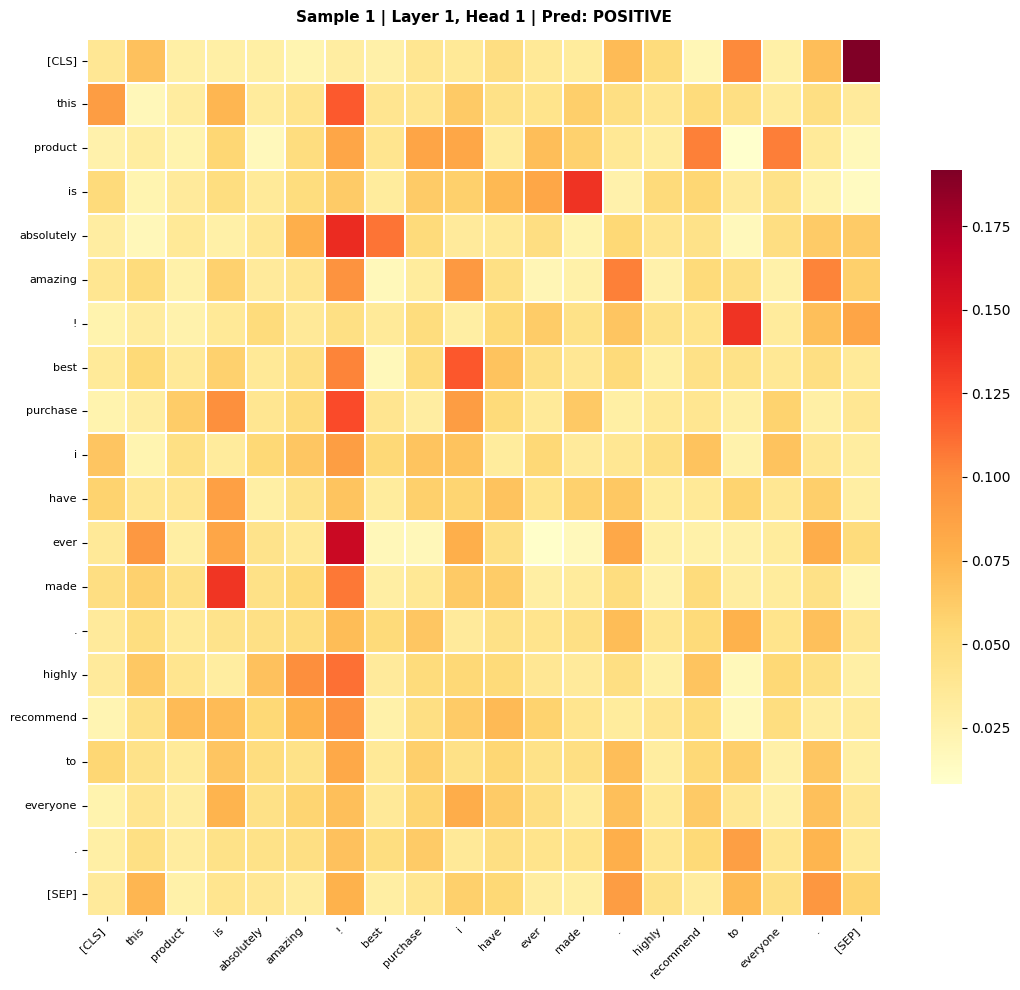

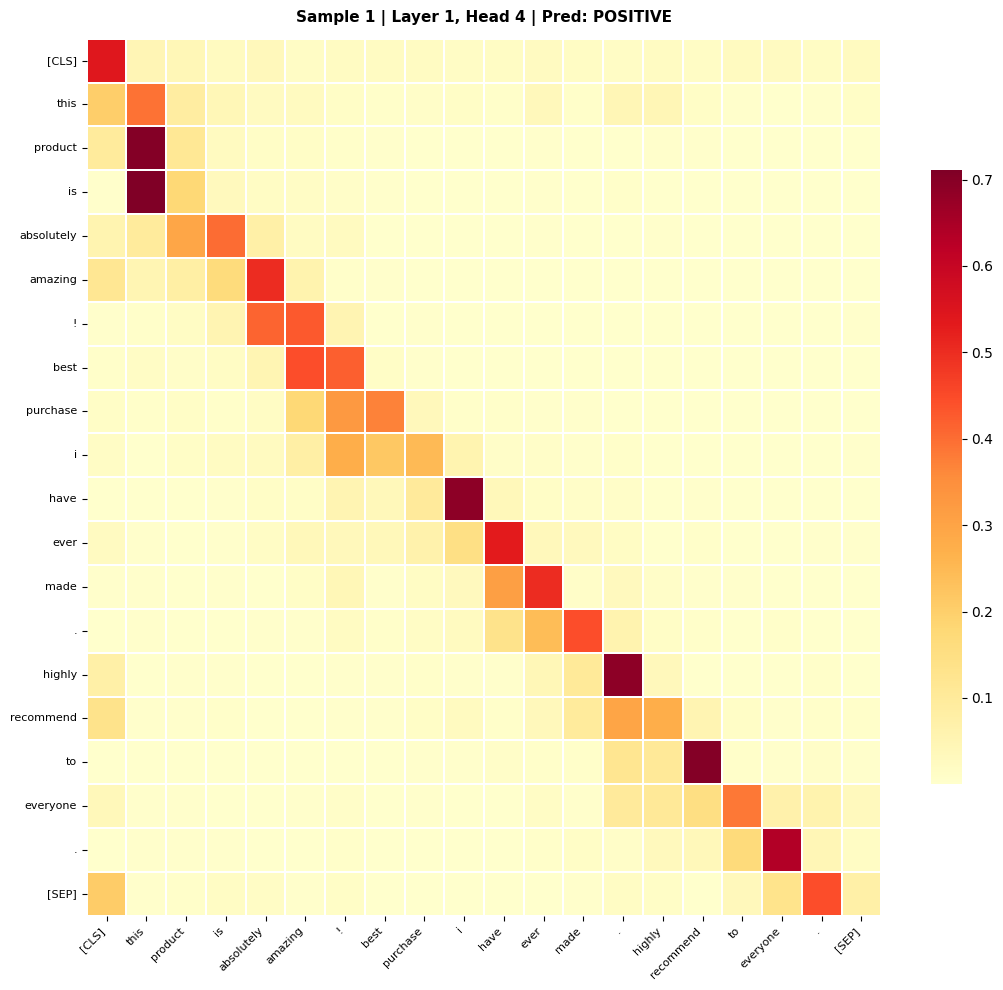

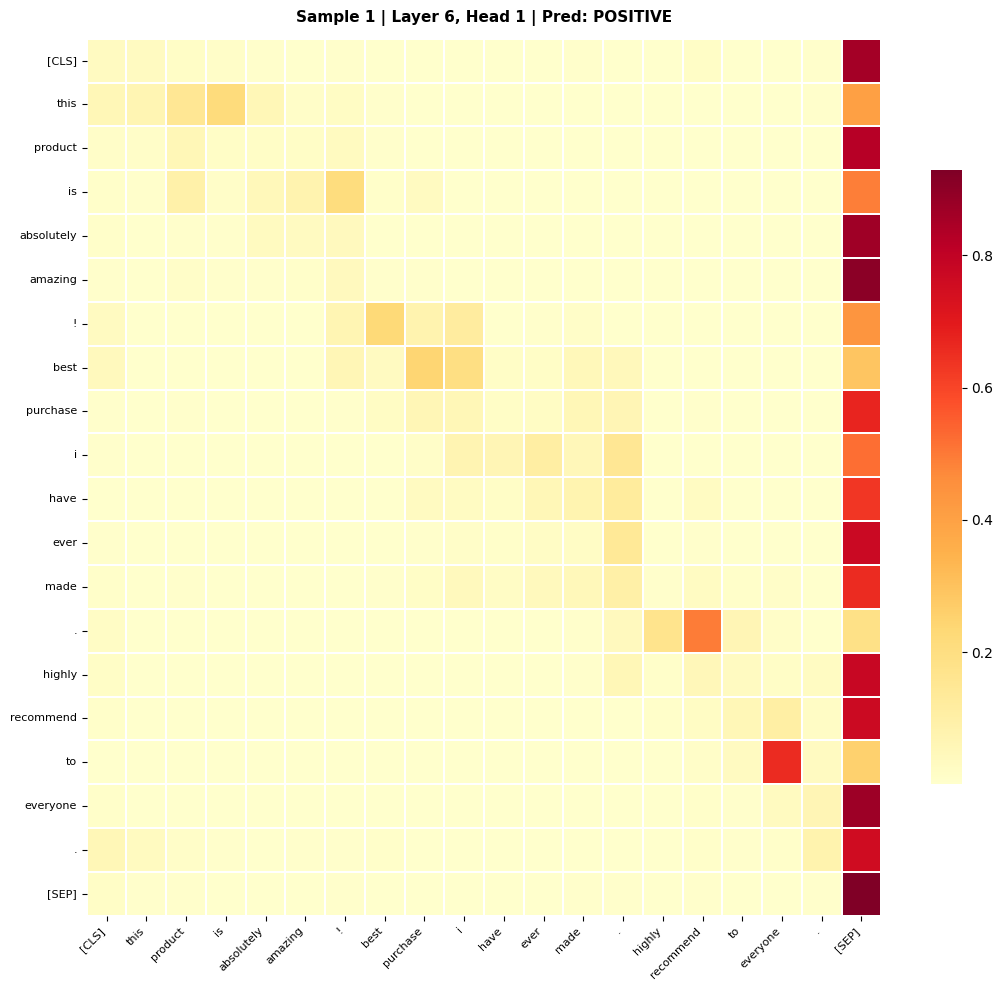

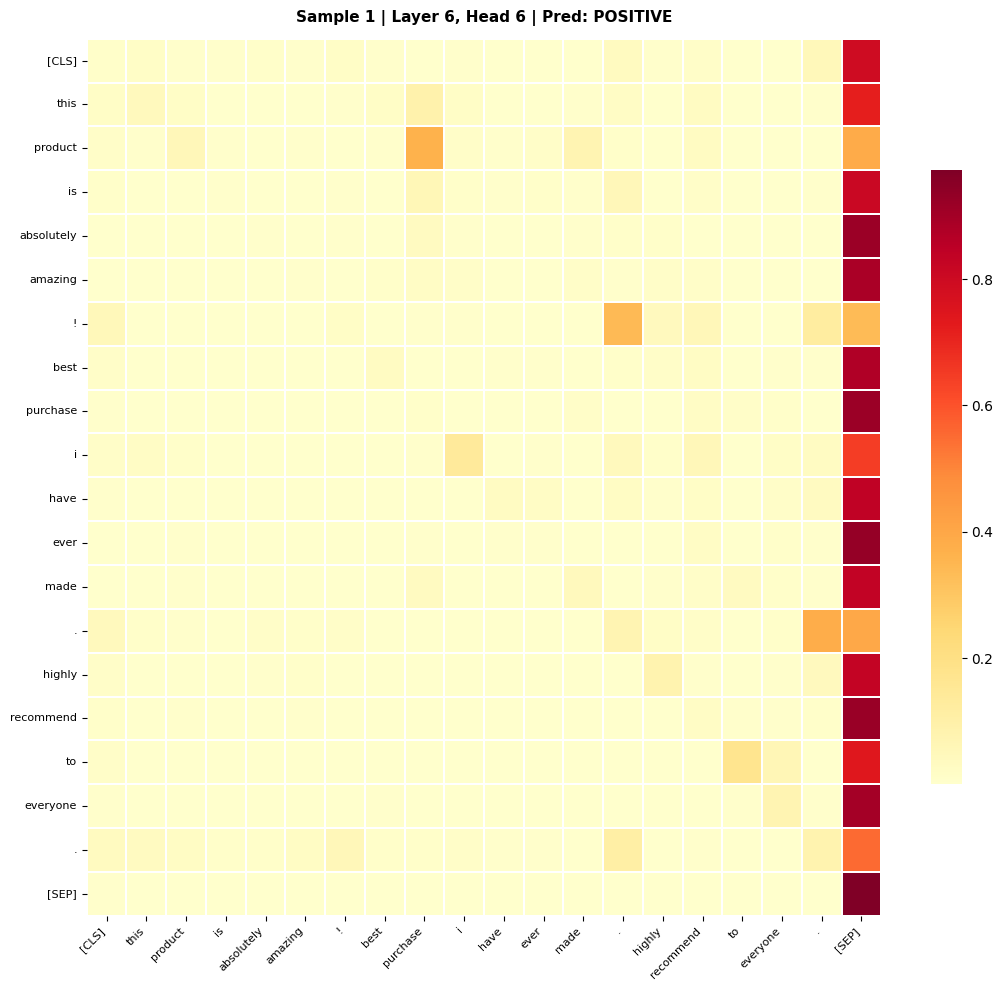

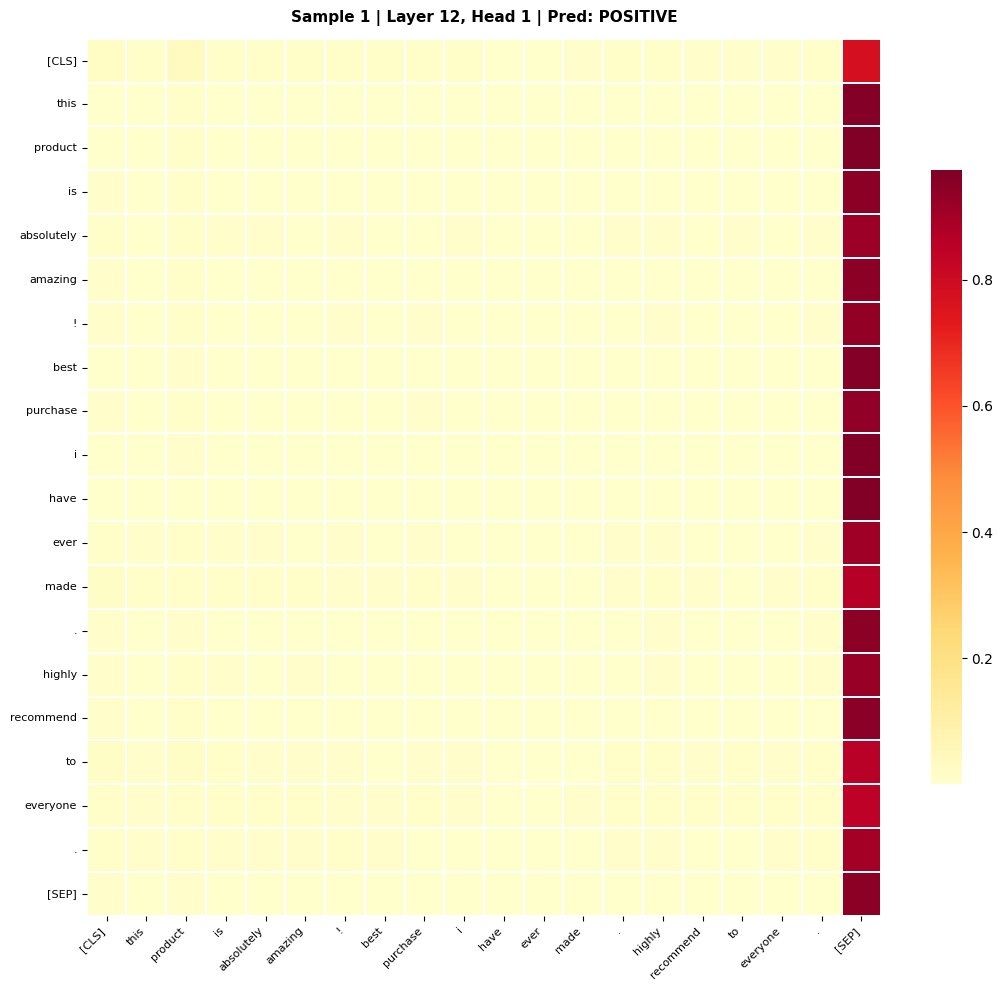

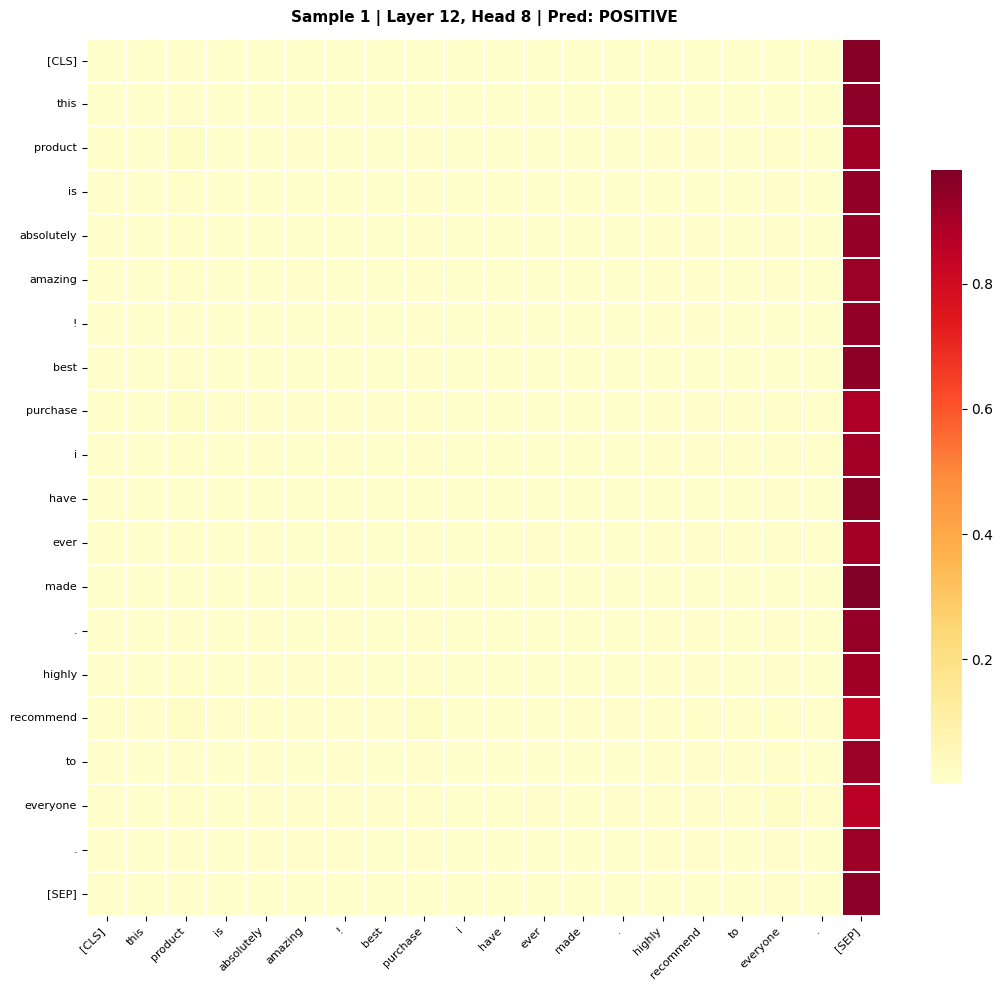

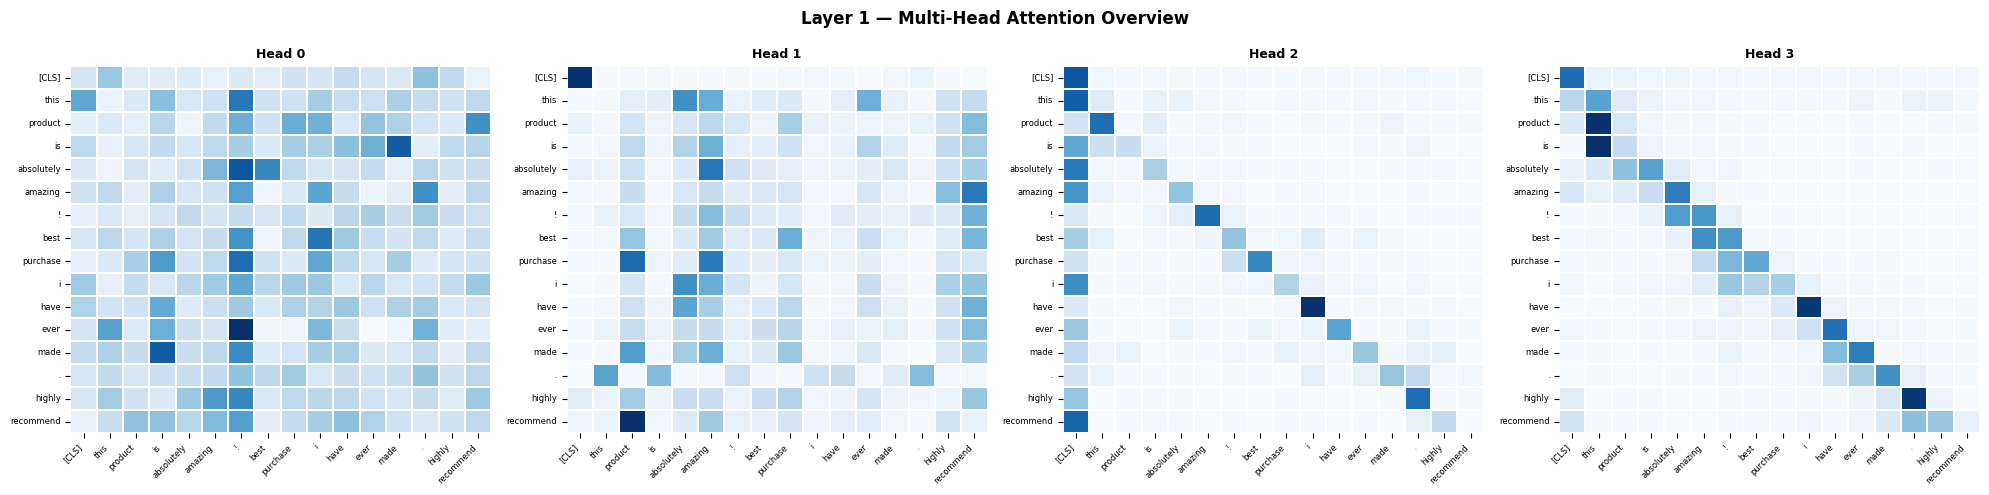

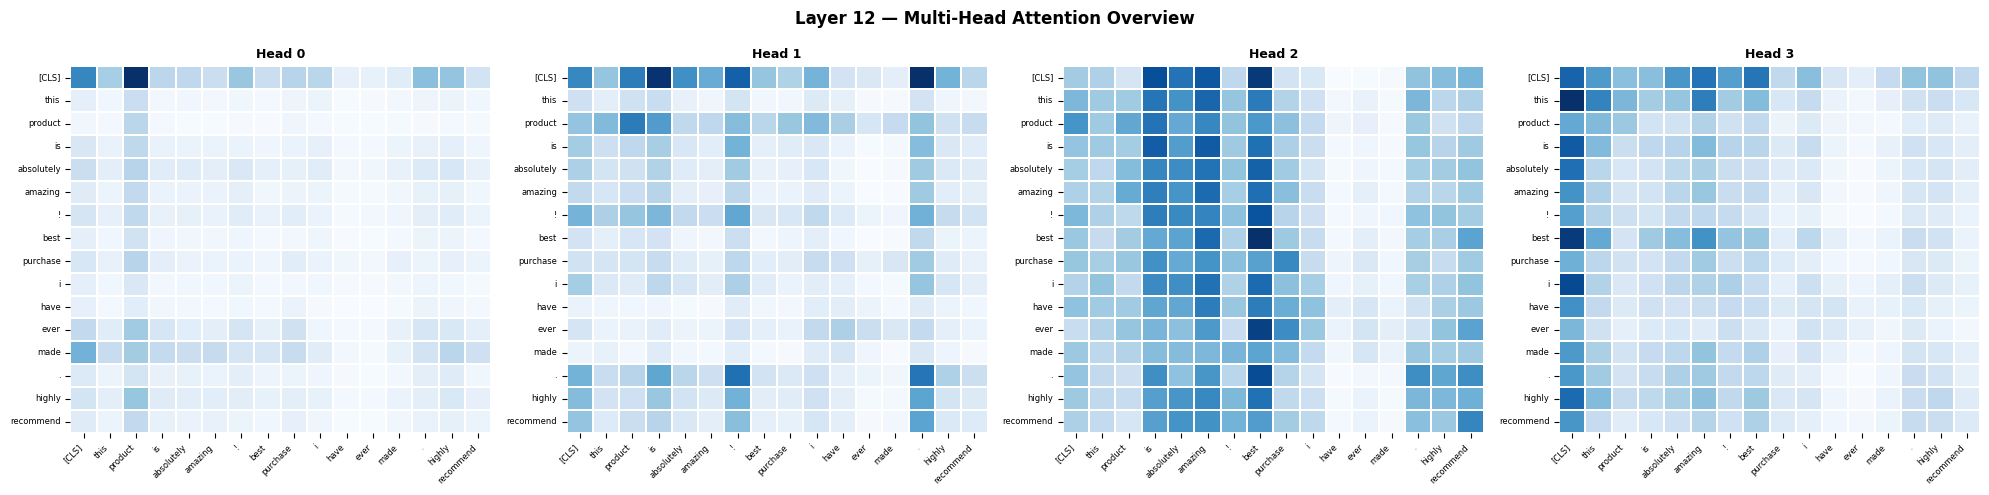


Sample 2: 'Terrible quality. Broke after two days. Complete waste ...' → NEGATIVE


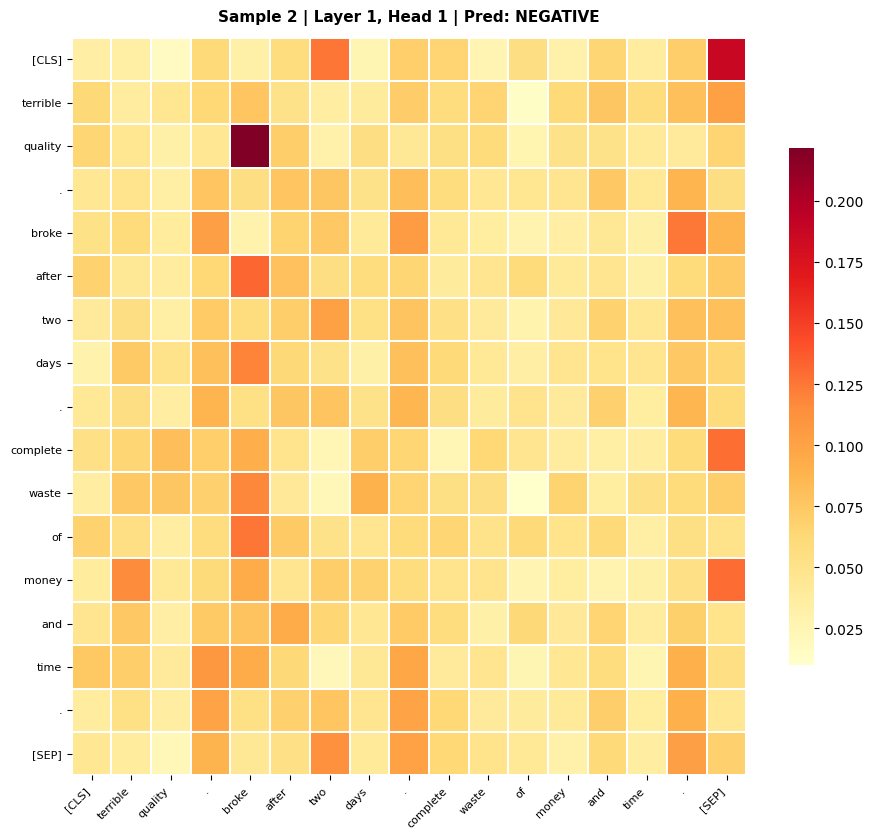

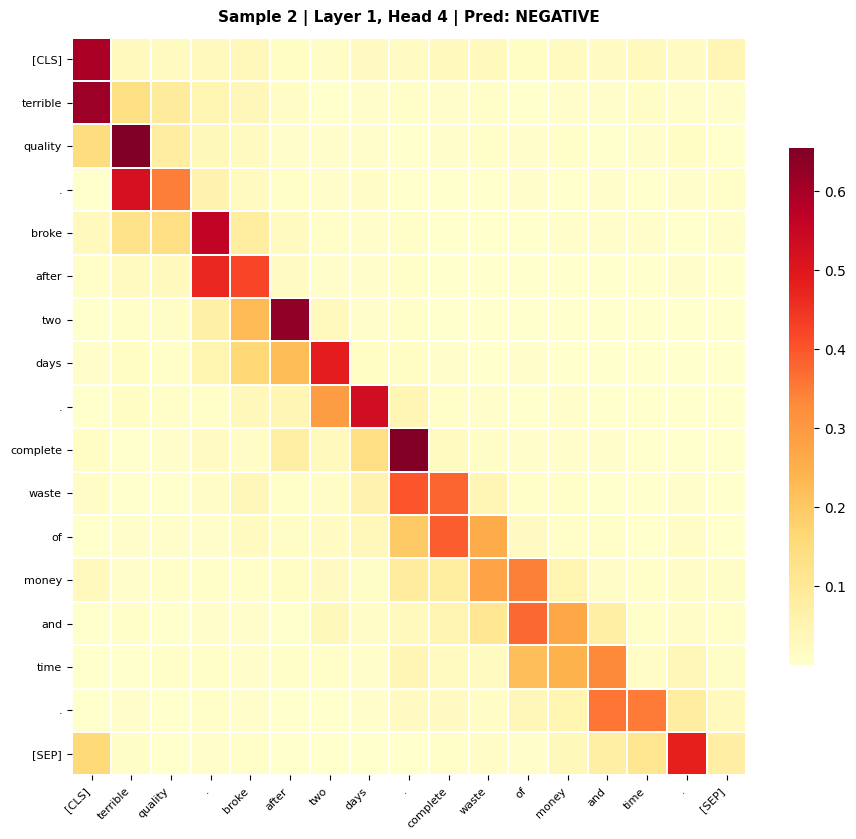

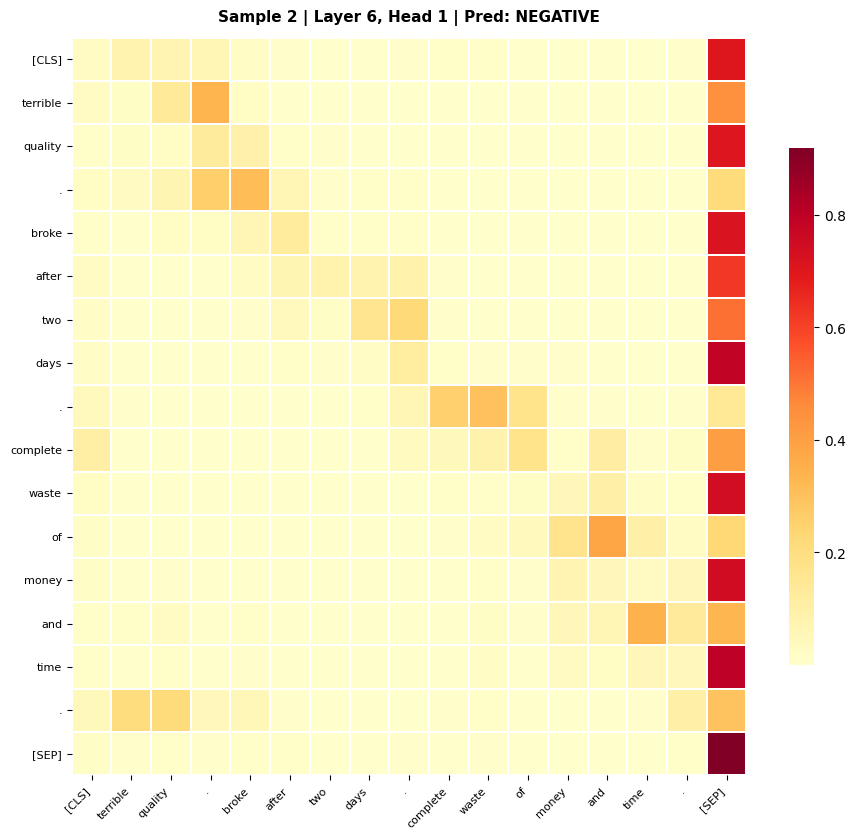

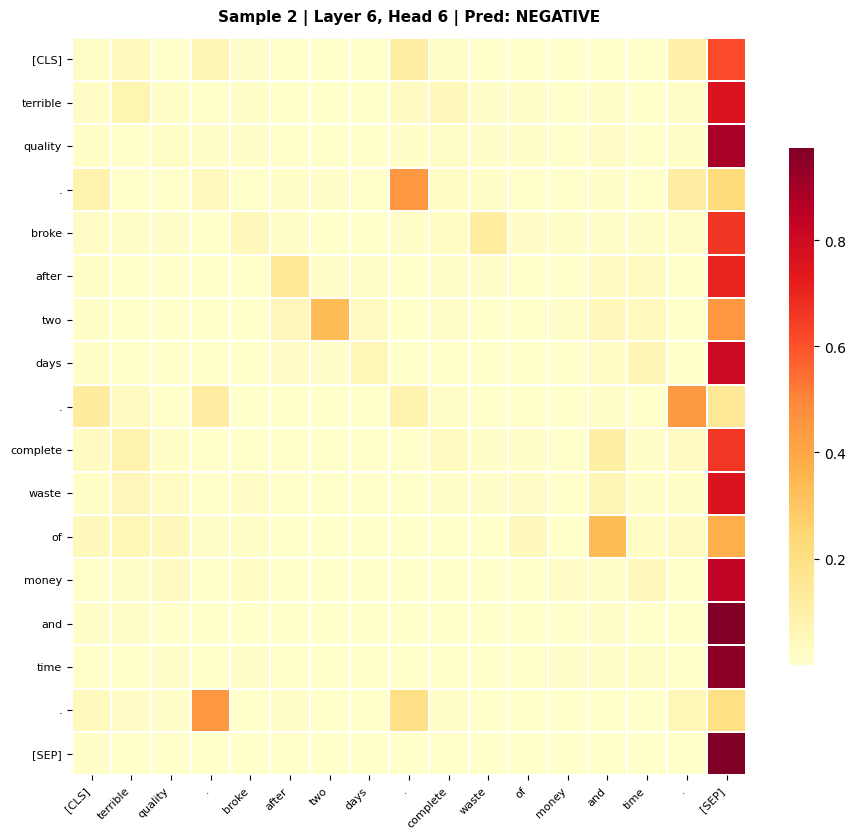

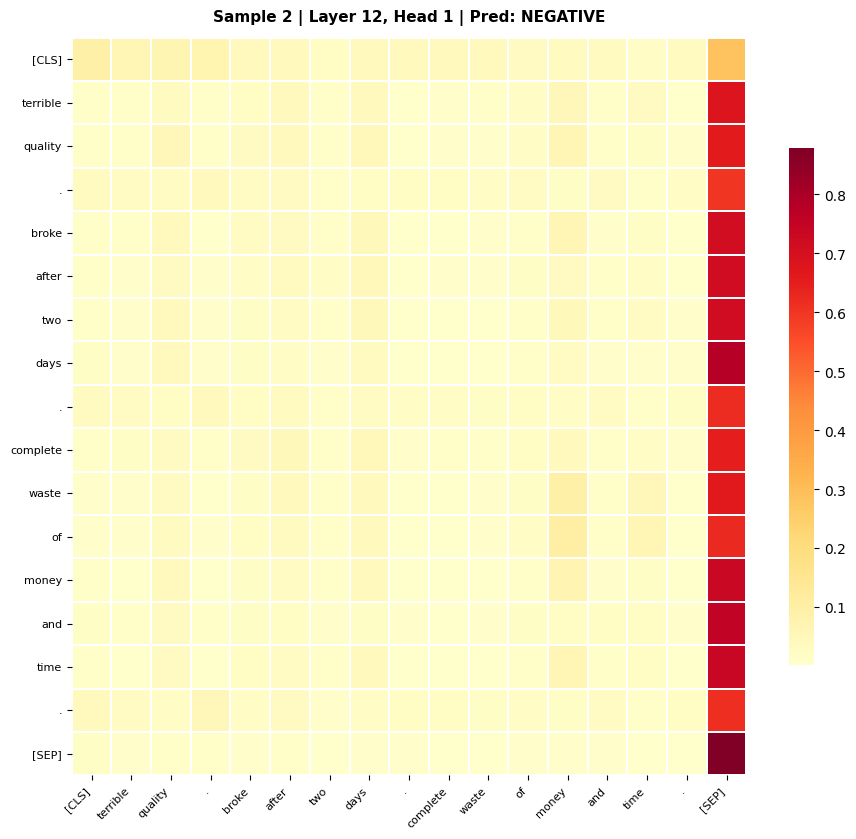

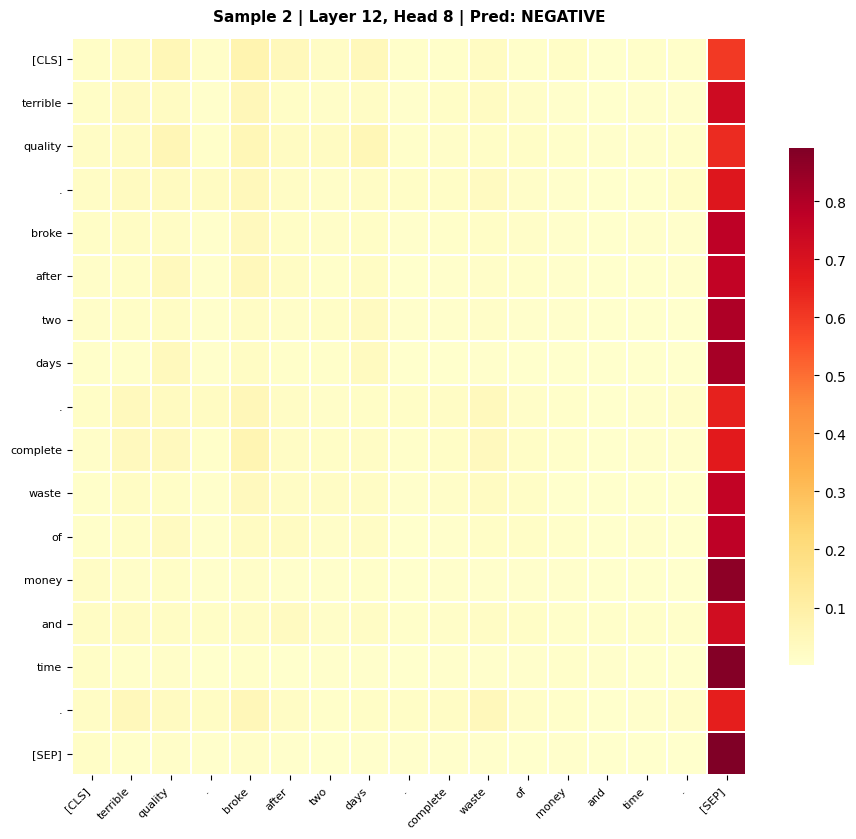

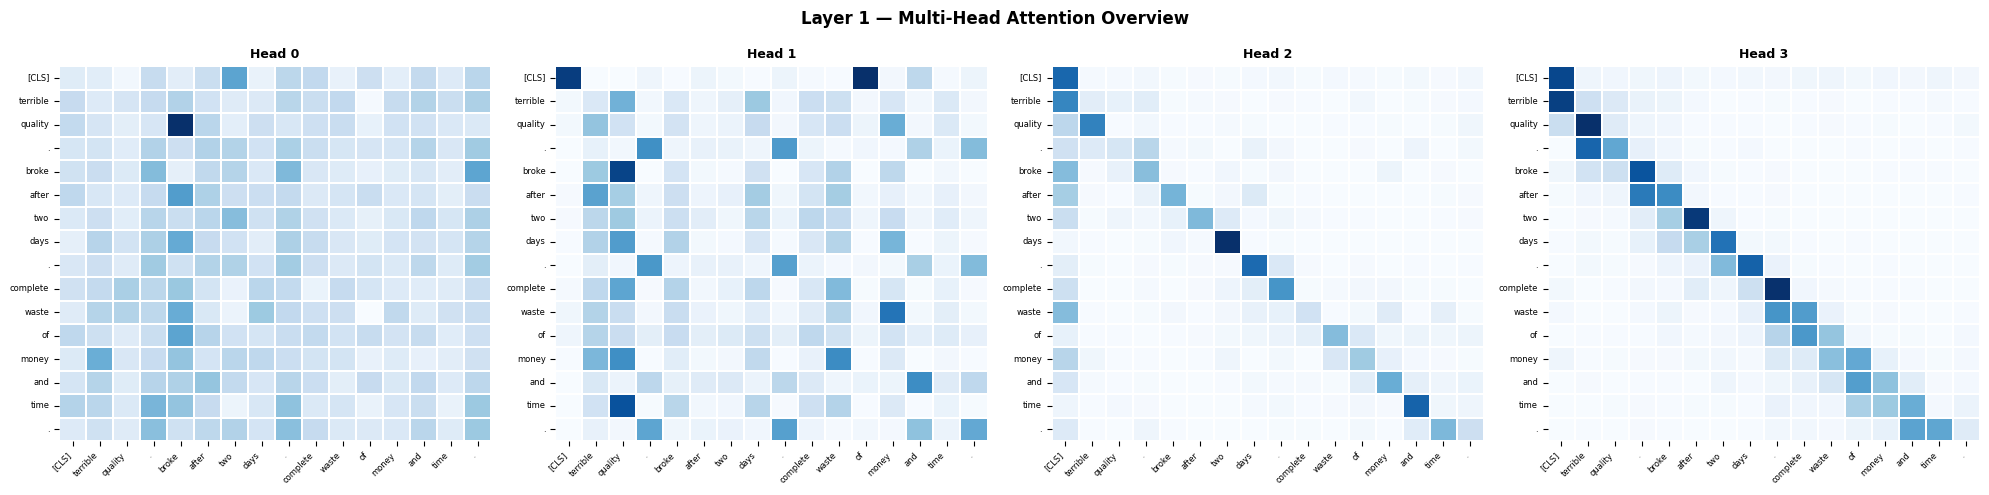

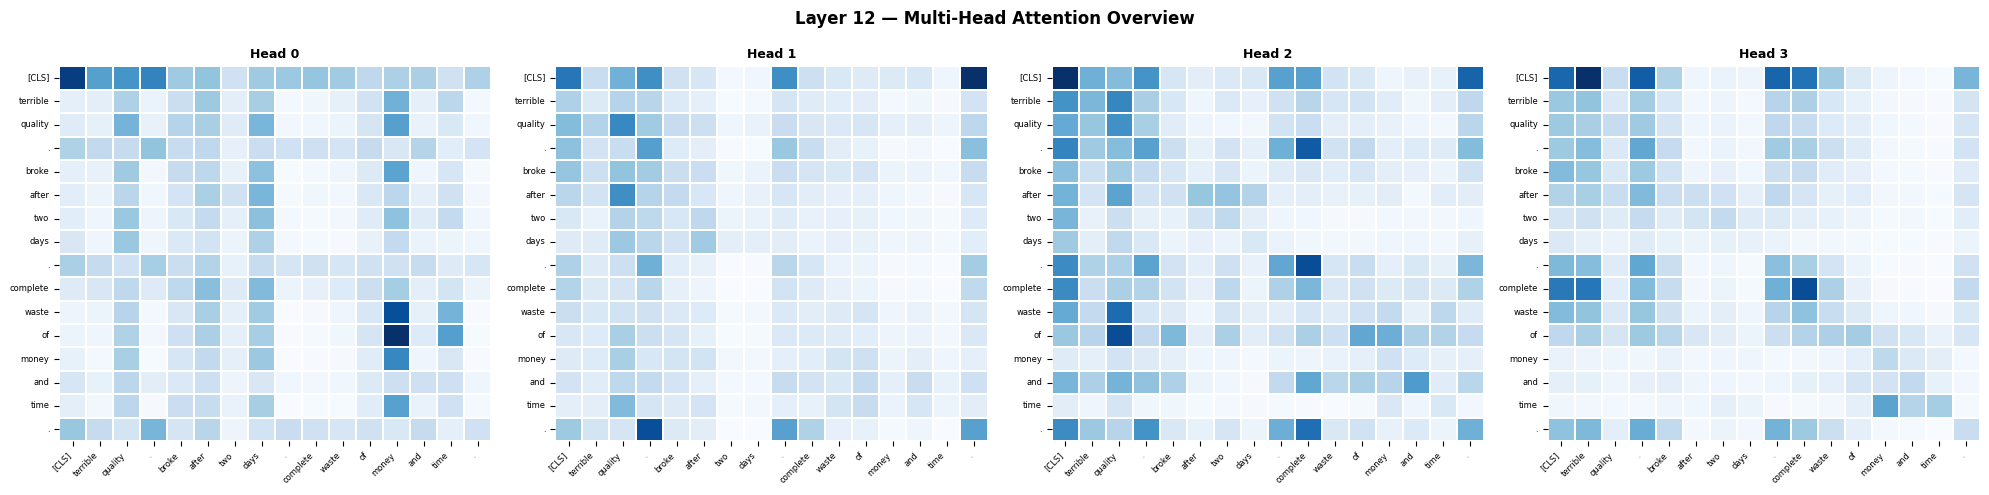


Sample 3: 'Great value for the price. Works exactly as described. ...' → POSITIVE


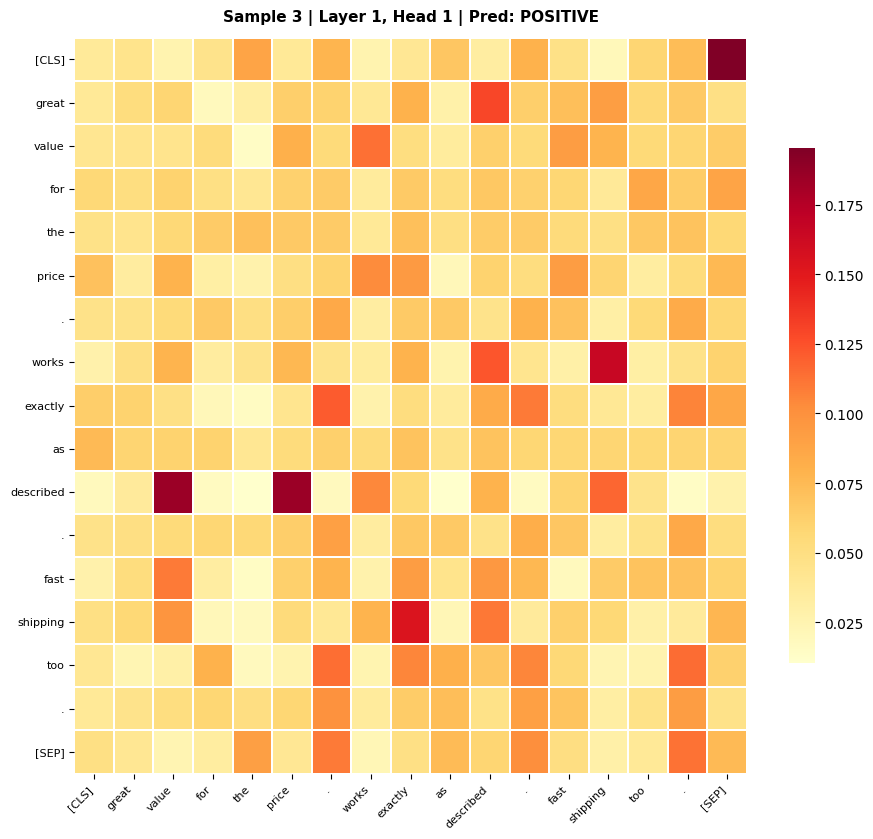

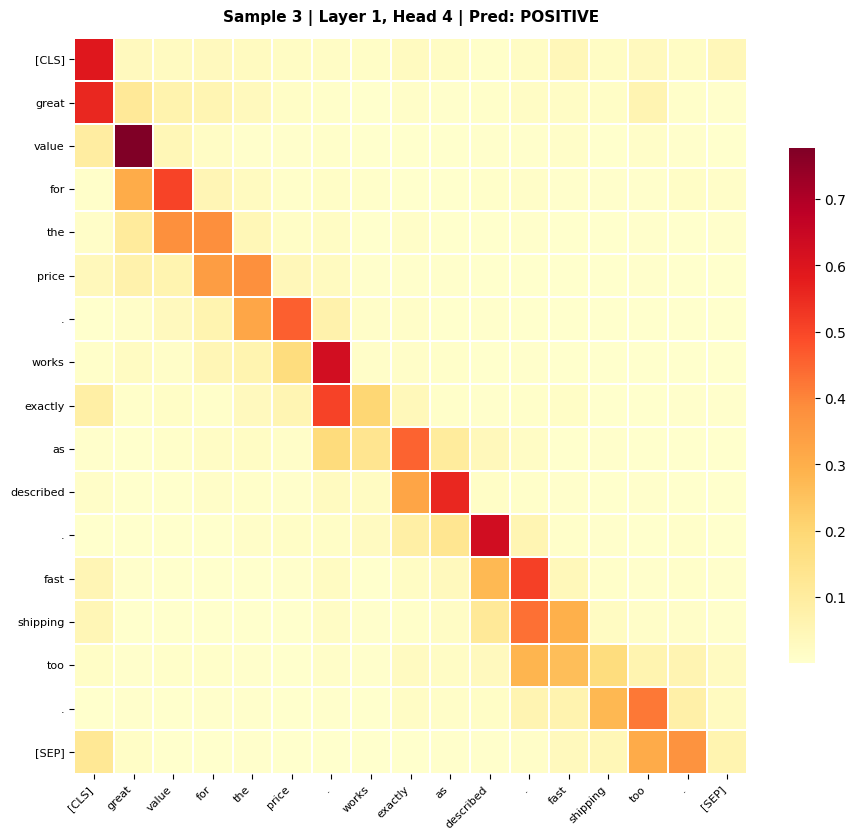

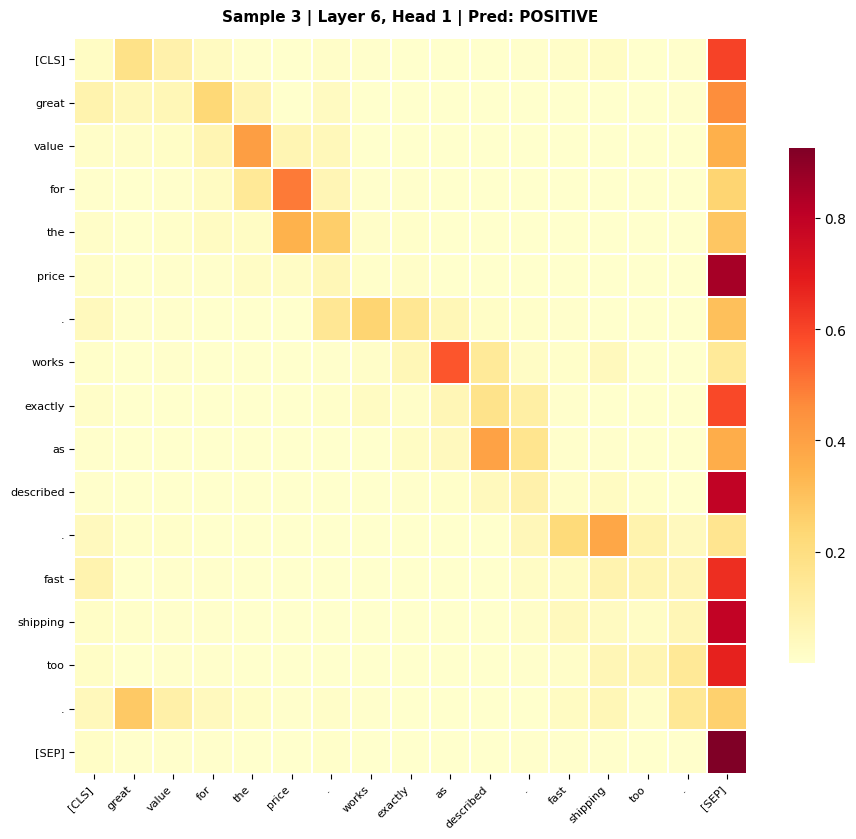

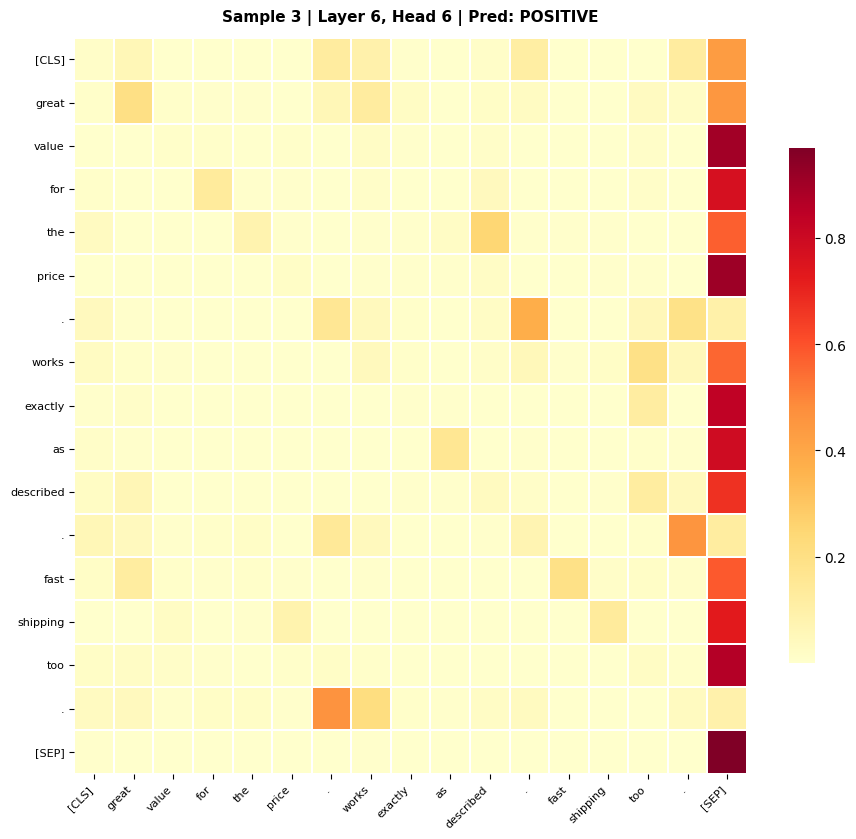

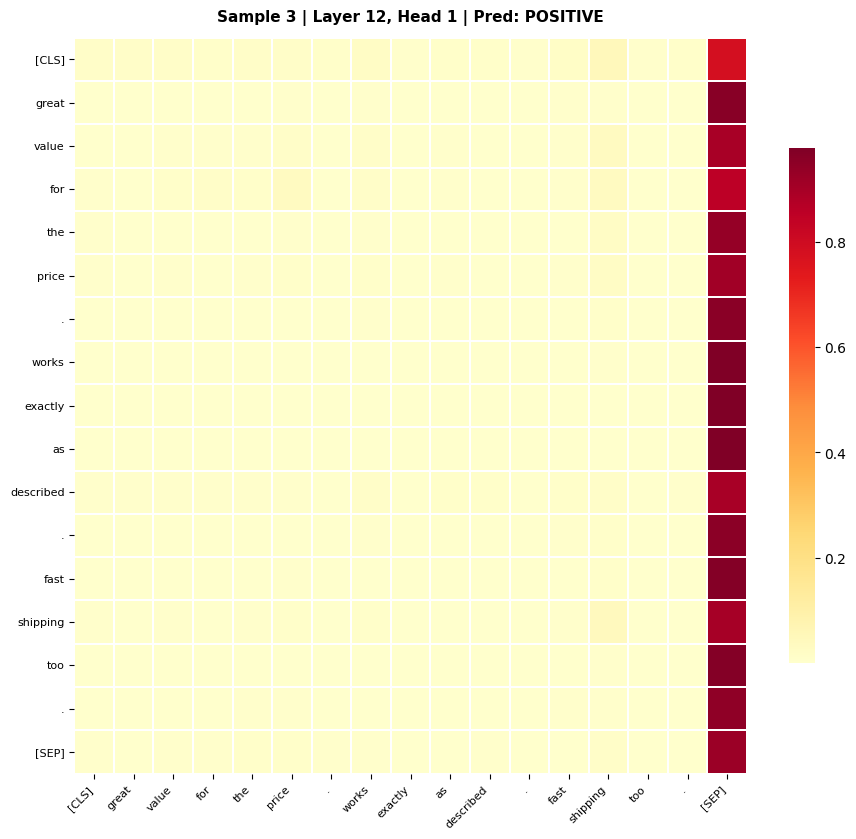

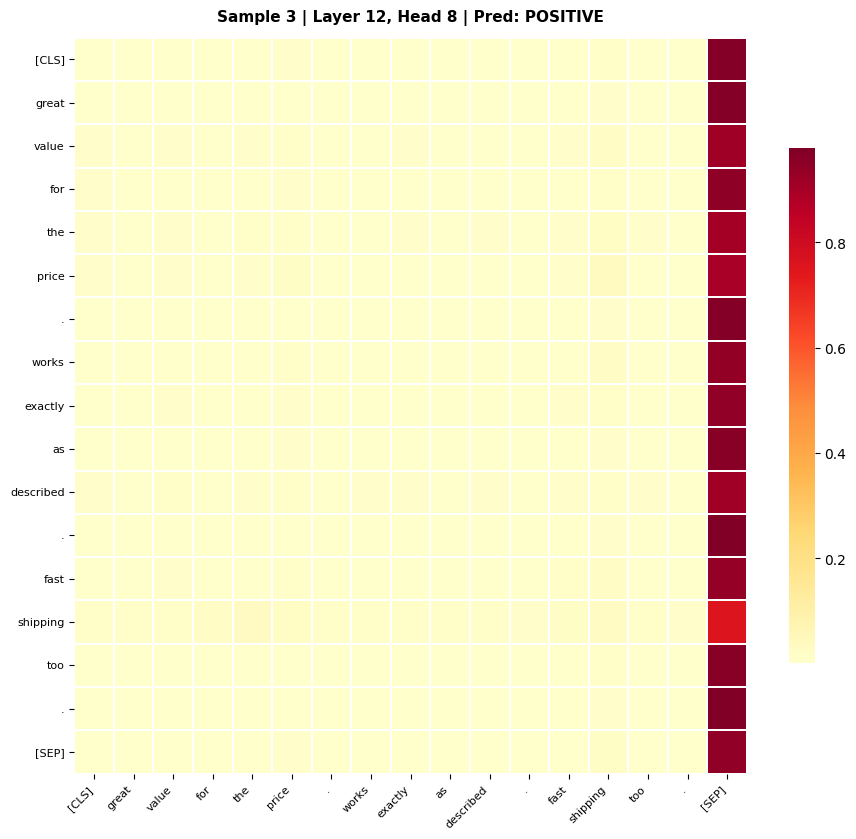

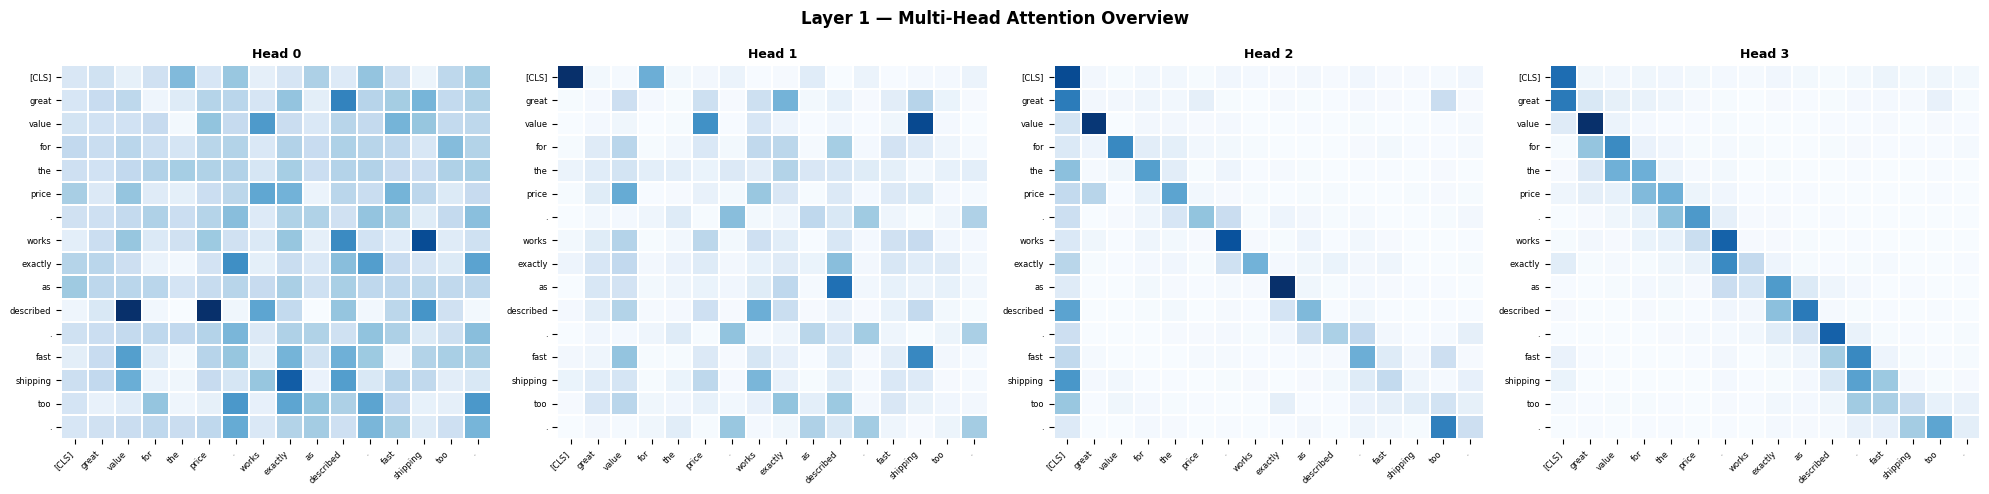

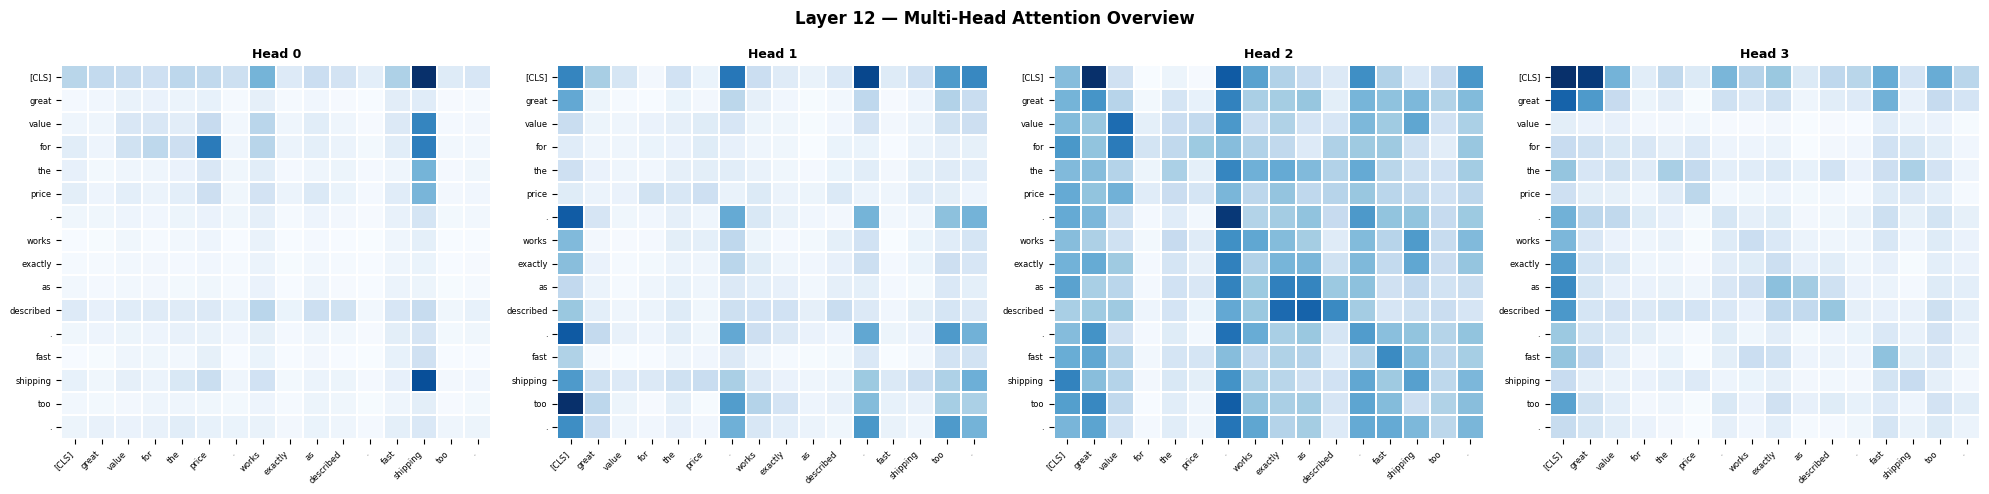


Sample 4: 'Disappointed with the product. Does not match the descr...' → NEGATIVE


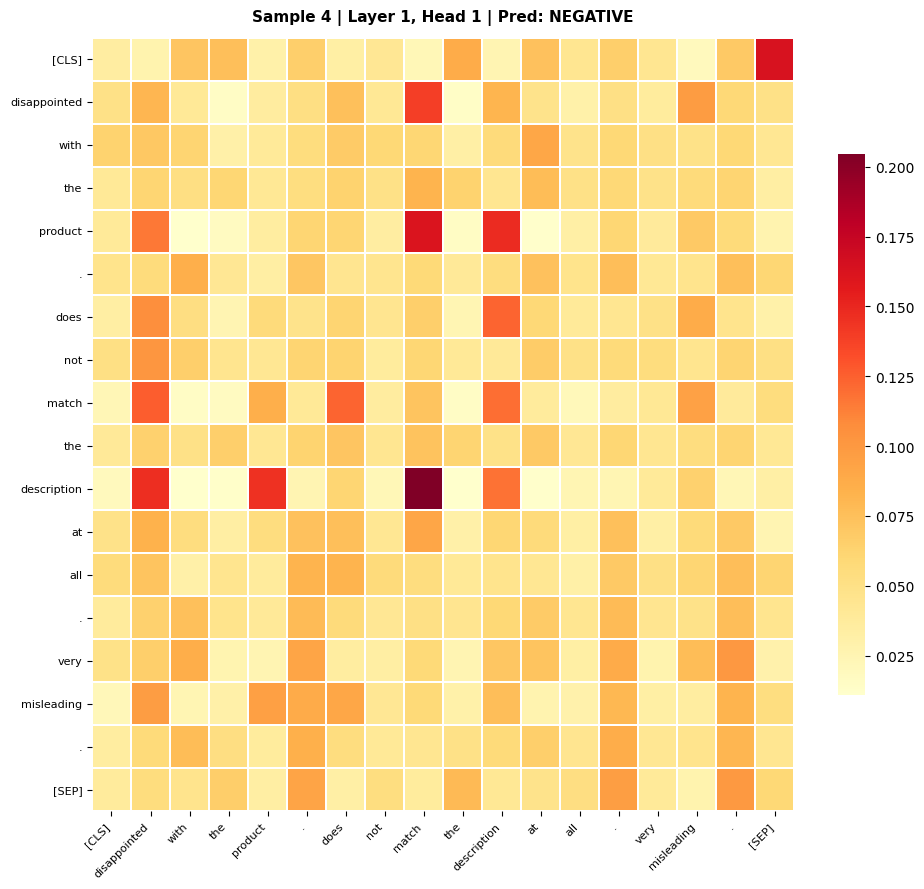

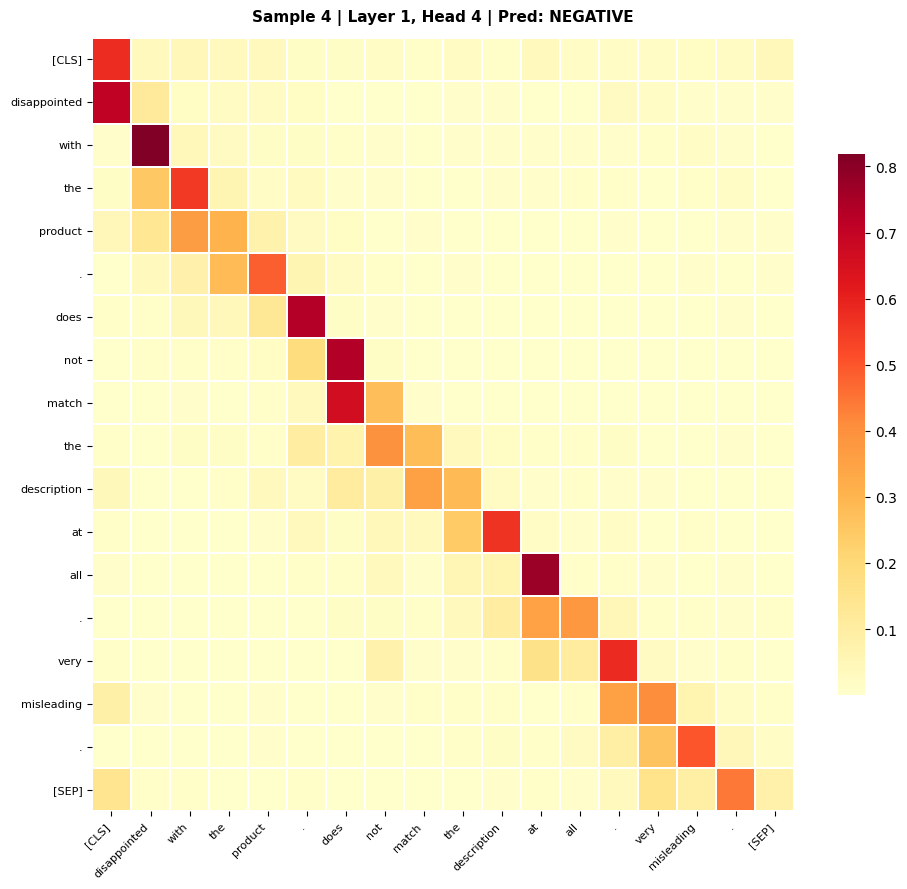

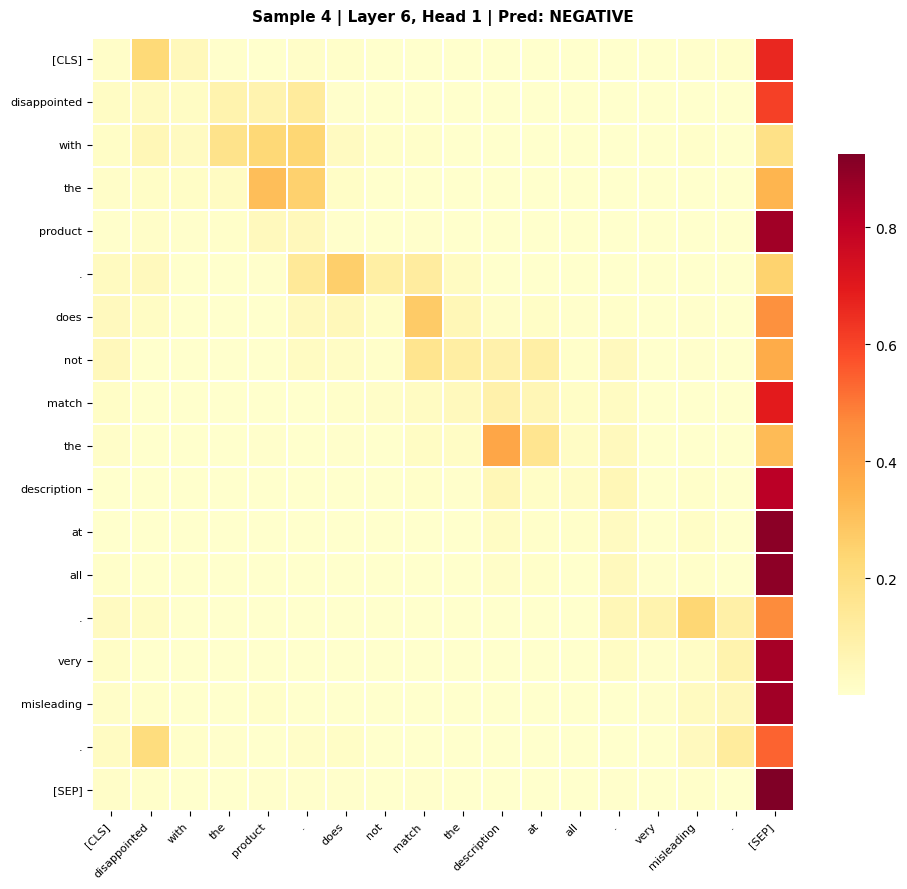

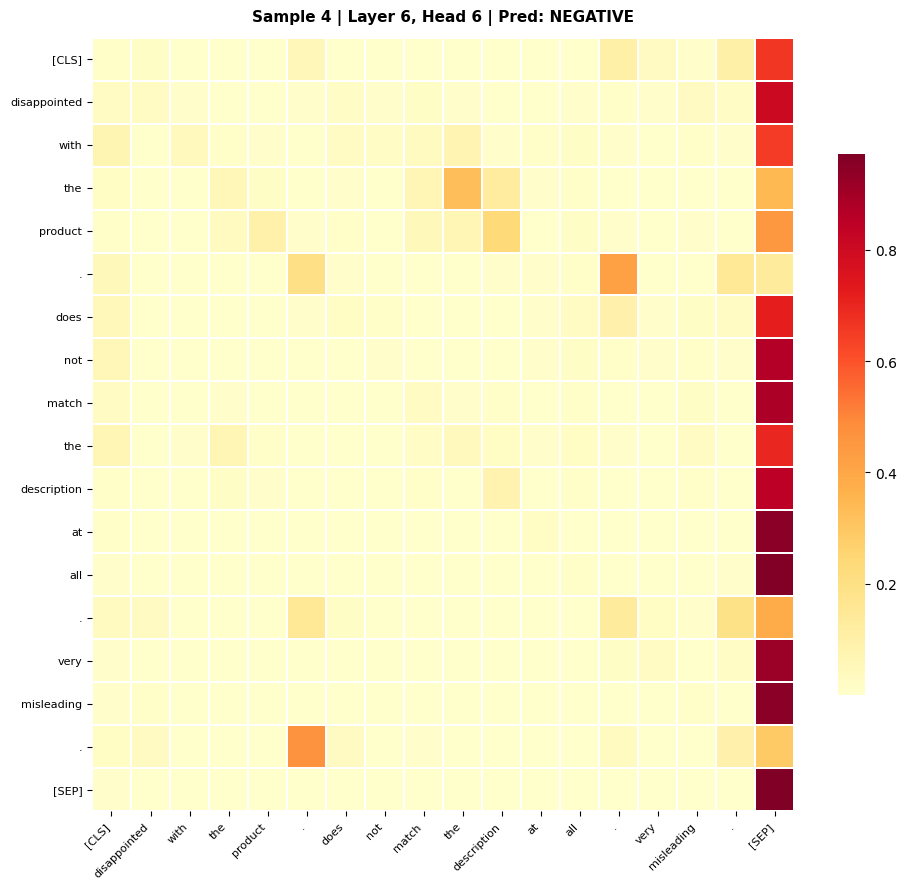

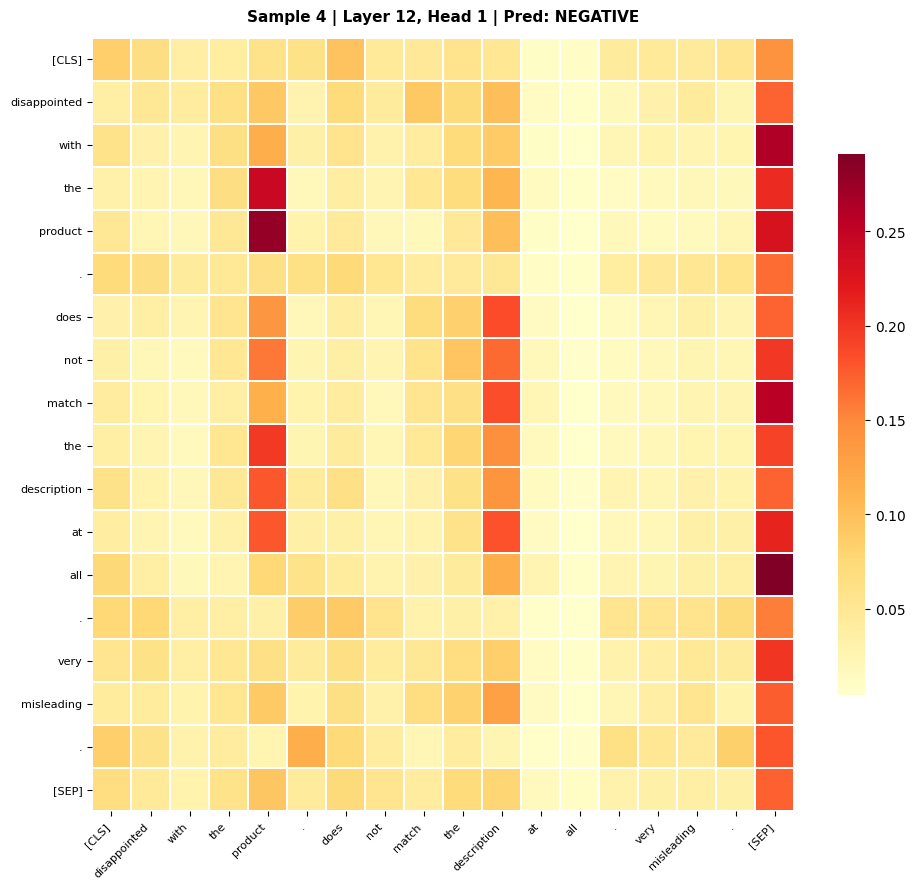

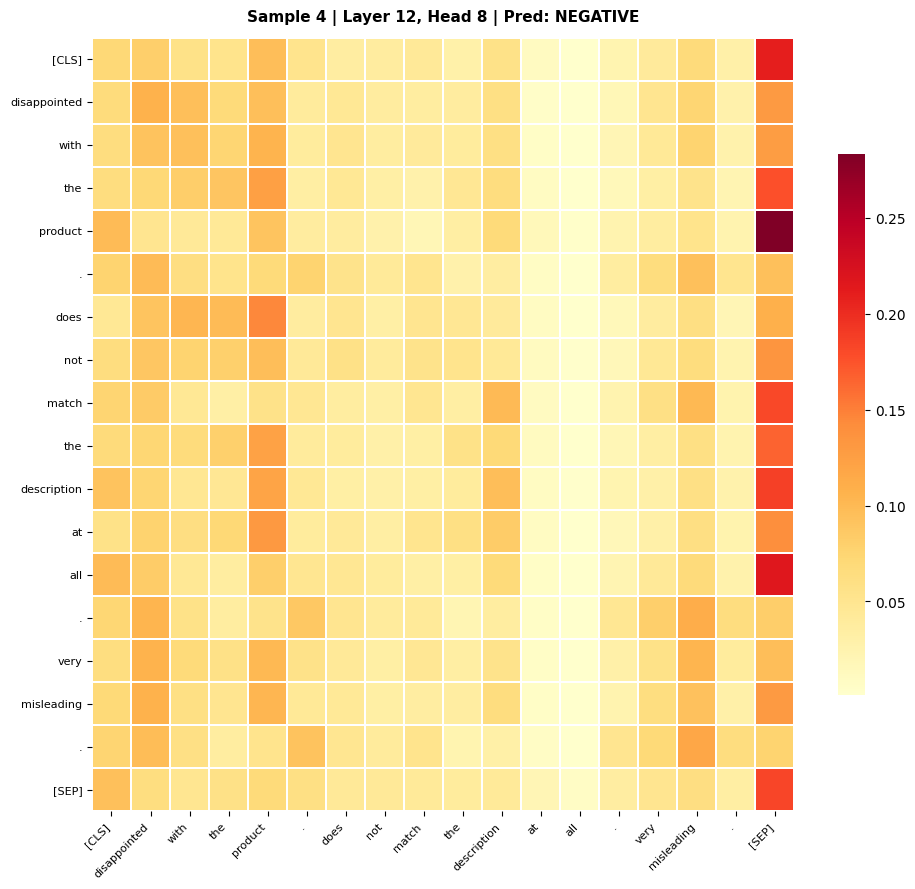

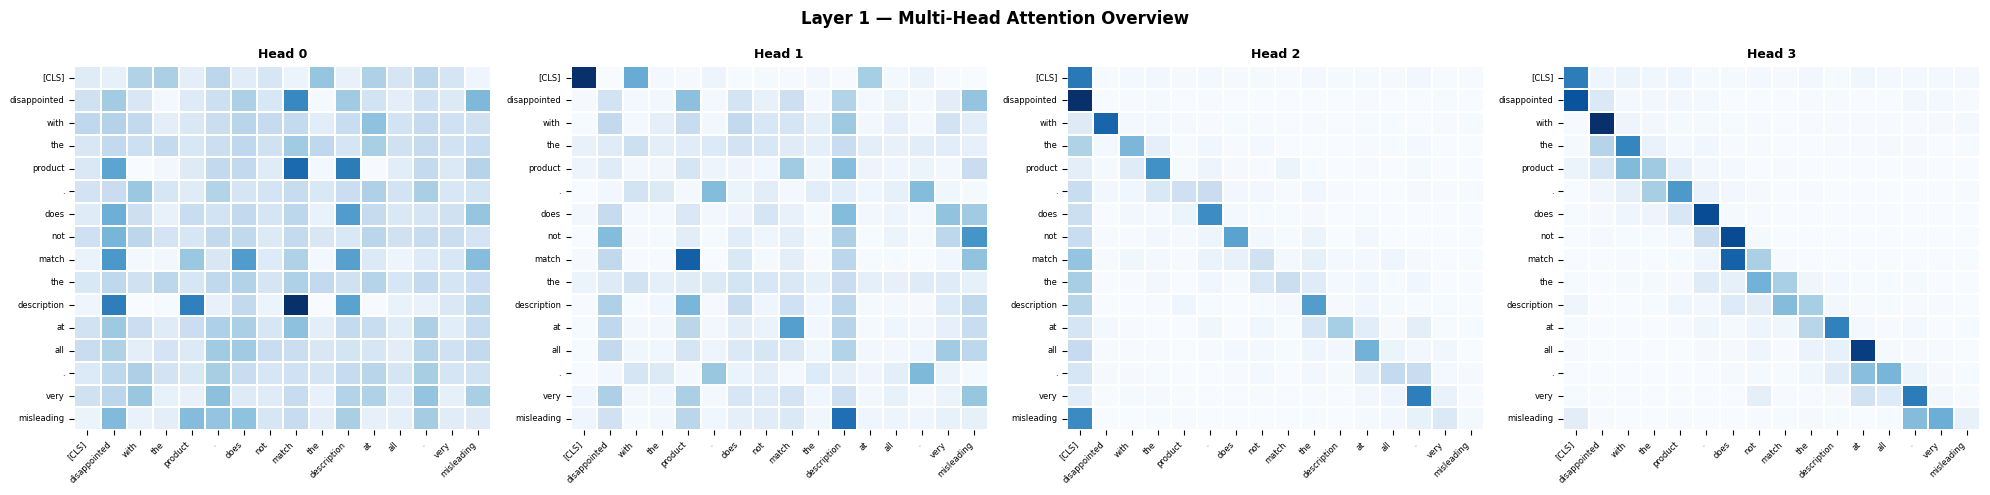

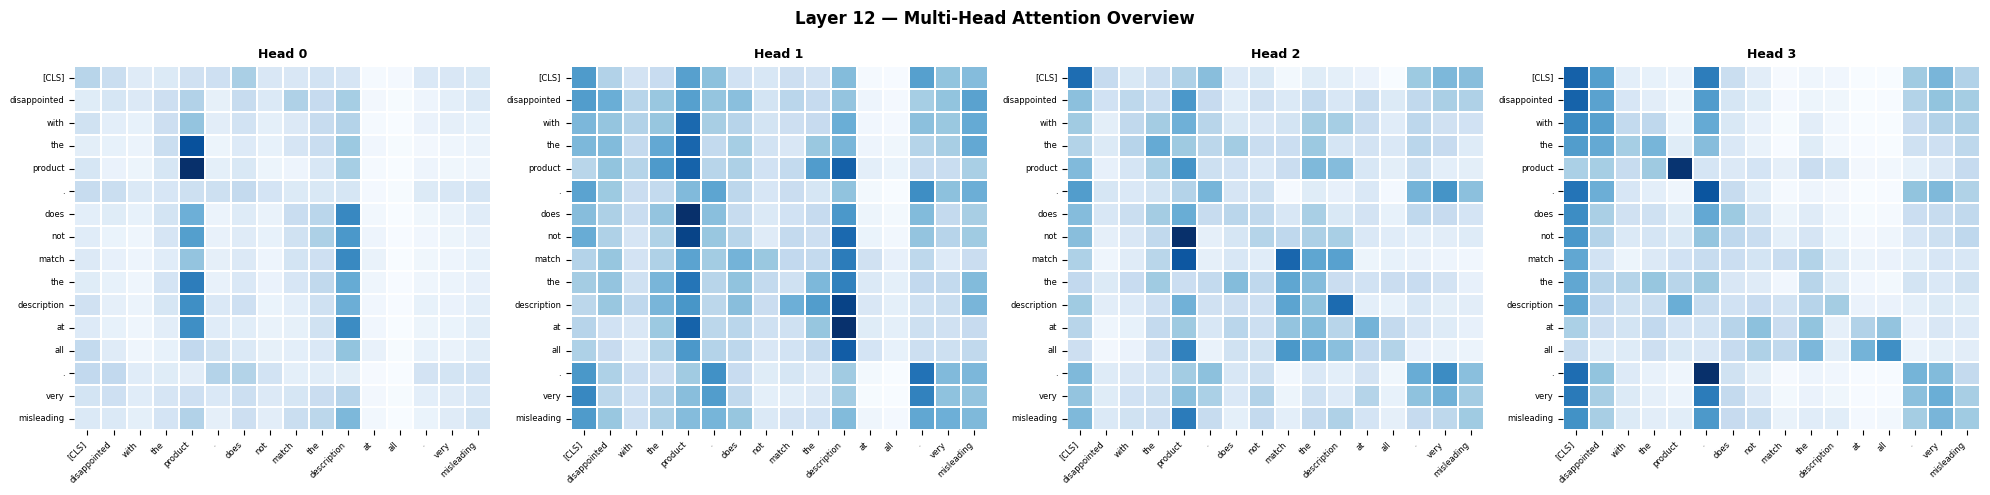

In [12]:
os.makedirs("./results/attention_maps", exist_ok=True)

SAMPLES = [
    "This product is absolutely amazing! Best purchase I have ever made. Highly recommend to everyone.",
    "Terrible quality. Broke after two days. Complete waste of money and time.",
    "Great value for the price. Works exactly as described. Fast shipping too.",
    "Disappointed with the product. Does not match the description at all. Very misleading.",
]

LAYER_HEAD_PAIRS = [(0, 0), (0, 3), (5, 0), (5, 5), (11, 0), (11, 7)]

for s_idx, text in enumerate(SAMPLES):
    tokens, attentions, pred_label = get_attention(text)
    print(f"\nSample {s_idx+1}: '{text[:55]}...' → {pred_label}")

    # Individual heatmaps for selected layer/head pairs
    for layer_idx, head_idx in LAYER_HEAD_PAIRS:
        title = f"Sample {s_idx+1} | Layer {layer_idx+1}, Head {head_idx+1} | Pred: {pred_label}"
        path  = f"./results/attention_maps/s{s_idx+1}_L{layer_idx+1}_H{head_idx+1}.png"
        plot_attention_heatmap(tokens, attentions[layer_idx, head_idx], title, save_path=path)

    # Multi-head overview for early and final layers
    for layer_idx in [0, 11]:
        path = f"./results/attention_maps/s{s_idx+1}_layer{layer_idx+1}_multihead.png"
        plot_multihead(tokens, attentions[layer_idx], layer_idx+1, save_path=path)

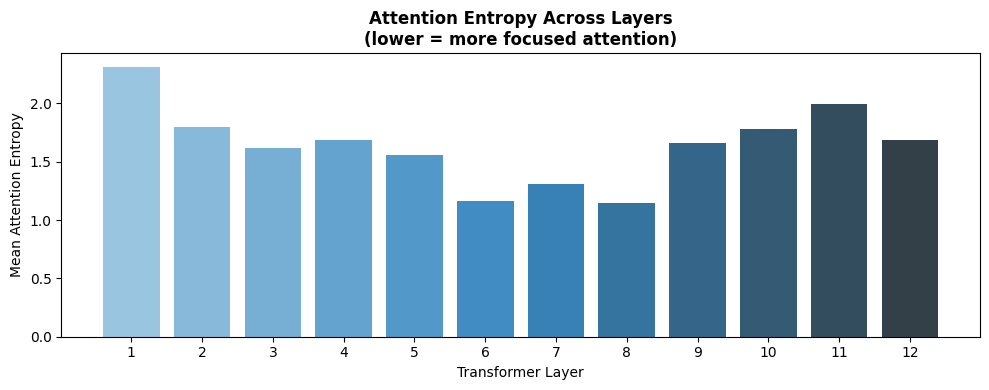

In [13]:
# ── Attention Entropy Across Layers ───────────────────────────────────
tokens, attentions, _ = get_attention(SAMPLES[0])
try:
    pad_idx = tokens.index("[PAD]")
except ValueError:
    pad_idx = len(tokens)

entropies = []
for layer_idx in range(attentions.shape[0]):
    att = attentions[layer_idx, :, :pad_idx, :pad_idx]
    eps = 1e-9
    ent = -np.sum(att * np.log(att + eps), axis=-1)
    entropies.append(ent.mean())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), entropies, color=sns.color_palette("Blues_d", 12))
ax.set_xlabel("Transformer Layer")
ax.set_ylabel("Mean Attention Entropy")
ax.set_title("Attention Entropy Across Layers\n(lower = more focused attention)", fontweight="bold")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig("./results/attention_maps/entropy_by_layer.png", dpi=150)
plt.show()

## 8. SHAP Explainability
Using **PartitionExplainer** with a Text masker to compute token-level Shapley values.  
Generating explanations for **25 test samples** (≥20 required).


In [16]:
MODEL_PATH = "./results/bert_amazon_polarity"
N_EXPLAIN  = 25
SEED       = 42

shap_tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)
shap_model     = BertForSequenceClassification.from_pretrained(MODEL_PATH)
shap_model.eval()

clf_pipeline = pipeline(
    "text-classification",
    model=shap_model,
    tokenizer=shap_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True,
    truncation=True,
    max_length=128,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

def predict_proba(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    texts = [str(t) for t in texts]

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)   # ── send inputs to GPU ──

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        logits  = outputs.logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()  # back to CPU for SHAP
    return probs

# ── SHAP masker + explainer ───────────────────────────────────────────────────
masker    = shap.maskers.Text(r"\W+")
explainer = shap.Explainer(predict_proba, masker, output_names=["NEGATIVE", "POSITIVE"])

np.random.seed(SEED)
dataset    = load_dataset("fancyzhx/amazon_polarity")
test_split = dataset["test"].shuffle(seed=SEED).select(range(500))
texts_all  = [t + " [SEP] " + c for t, c in zip(test_split["title"], test_split["content"])]
labels_all = list(test_split["label"])

explain_texts  = texts_all[:N_EXPLAIN]
explain_labels = labels_all[:N_EXPLAIN]

masker    = shap.maskers.Text(shap_tokenizer)
explainer = shap.Explainer(predict_proba, masker, output_names=["NEGATIVE", "POSITIVE"])
print("SHAP explainer ready.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using device: cuda
SHAP explainer ready.


[01/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 9.8s


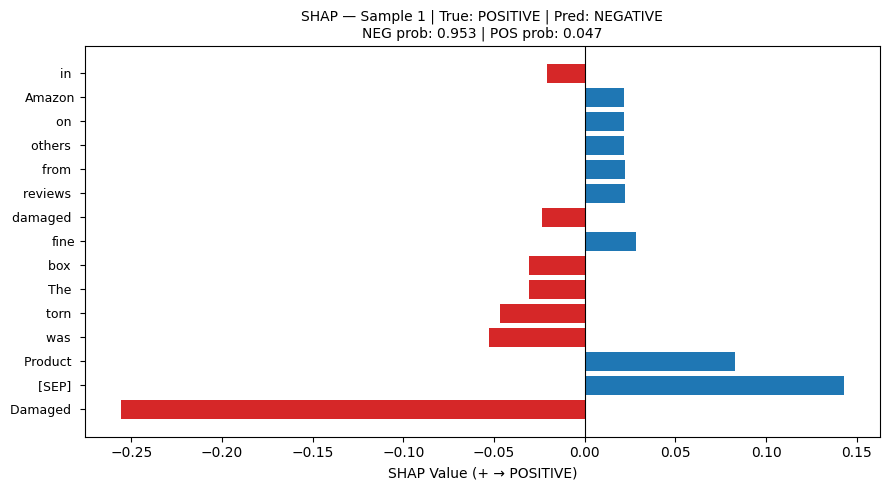

[02/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 1.9s


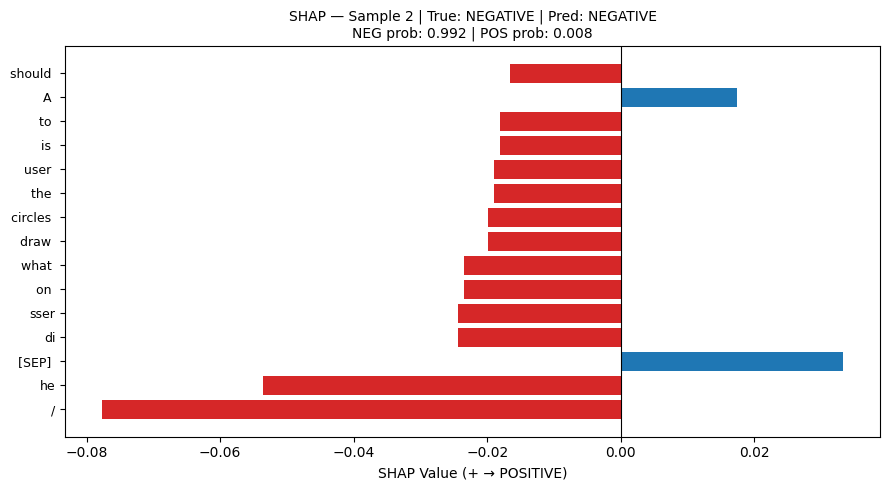

[03/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 1.8s


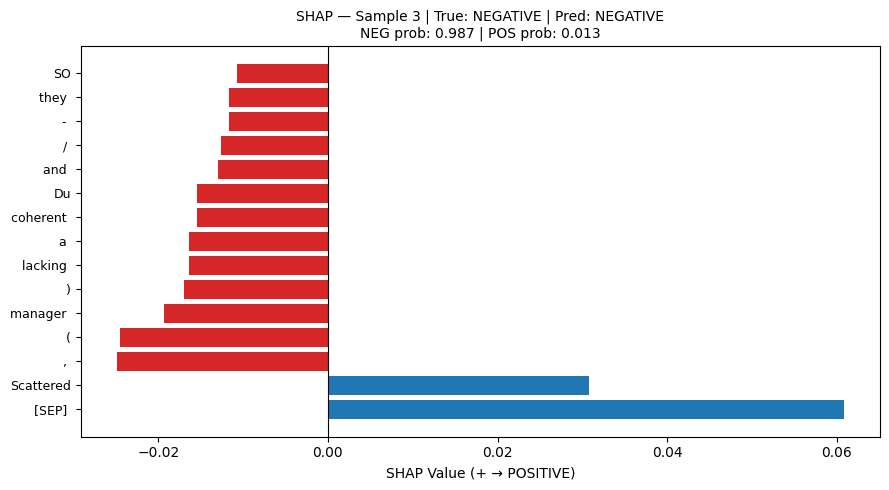

[04/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 2.0s


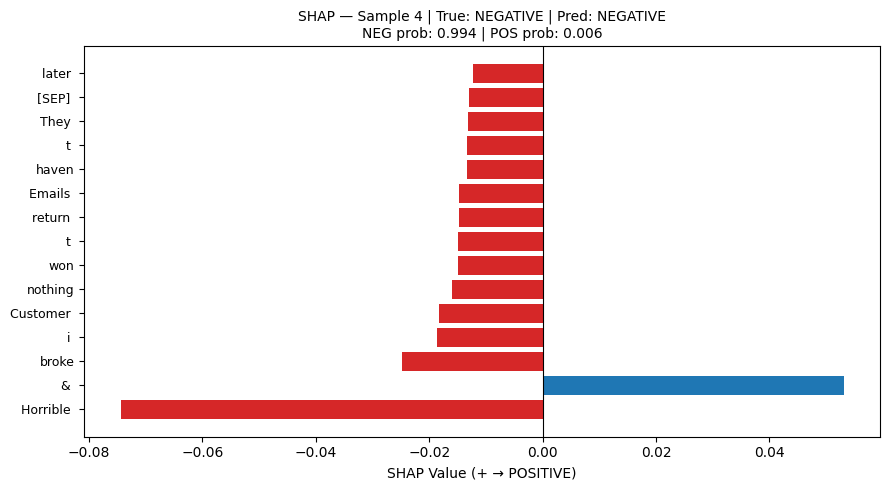

[05/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 2.3s


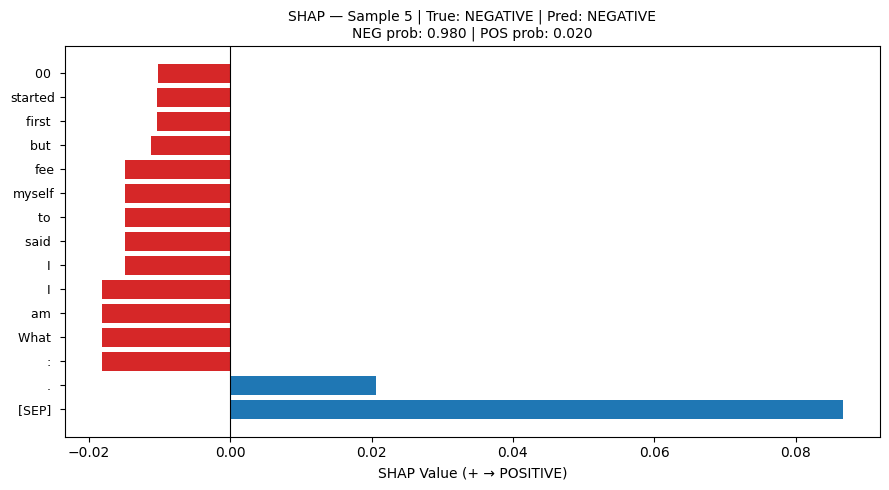

[06/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.7s


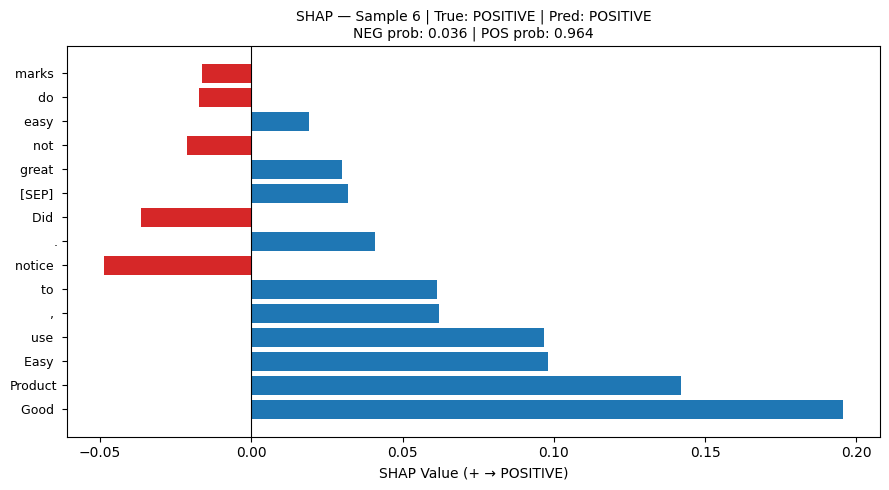

[07/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.6s


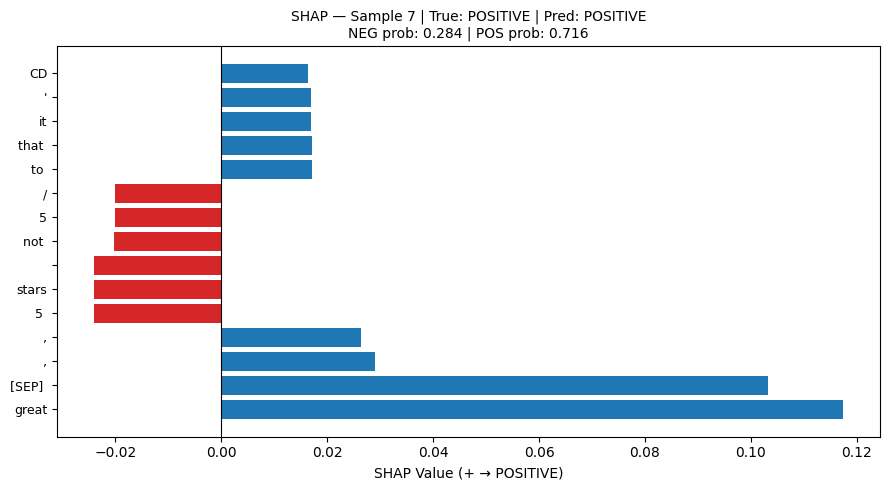

[08/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.7s


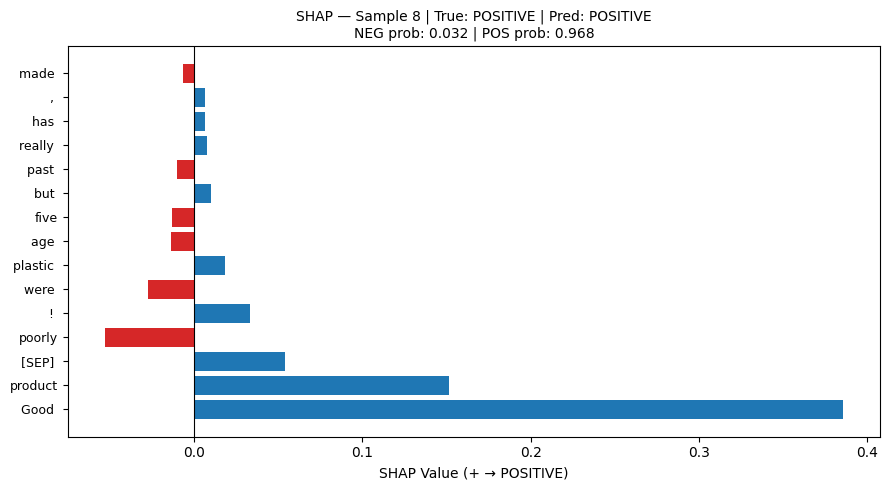

[09/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.0s


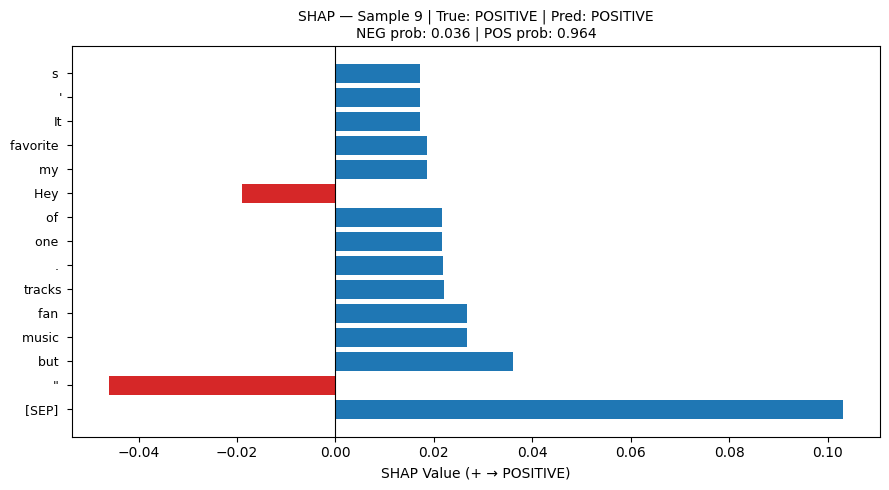

[10/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.6s


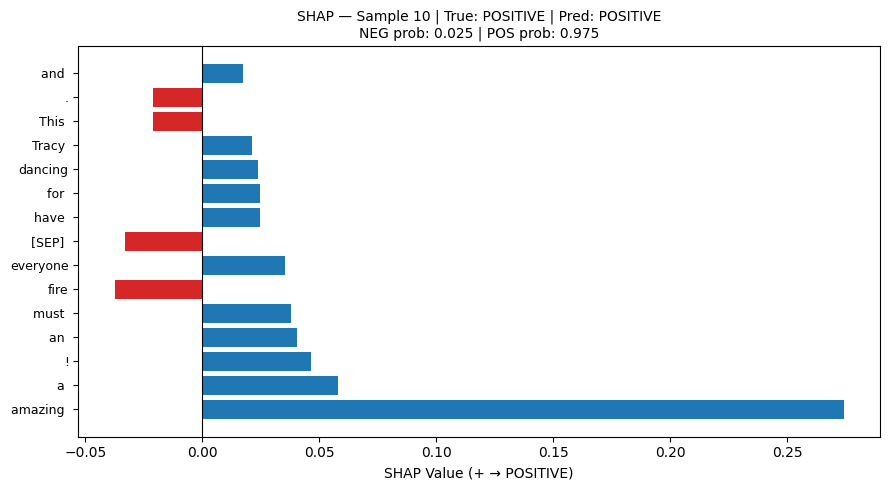

[11/25] True: NEGATIVE | Pred: POSITIVE | ✗ | 1.7s


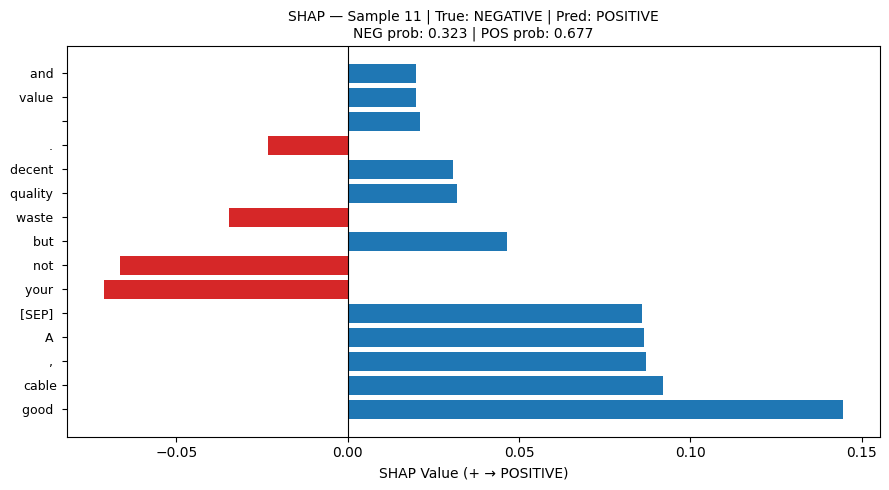

[12/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 2.6s


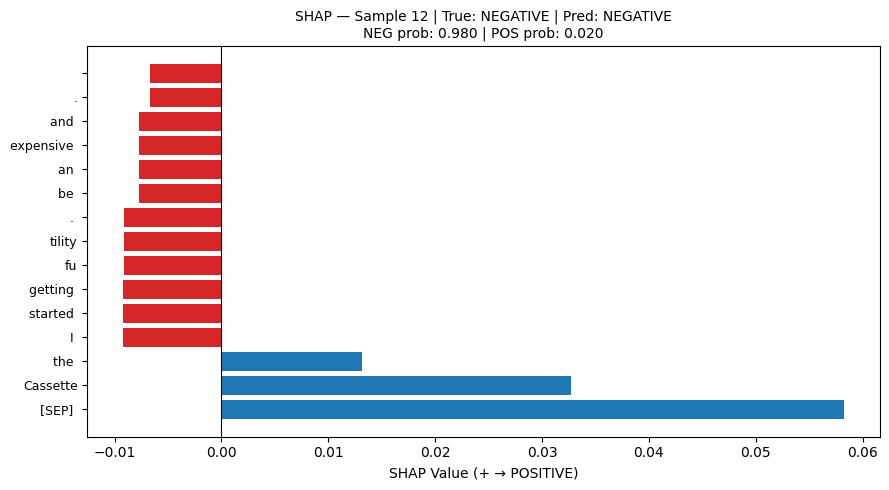

[13/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.7s


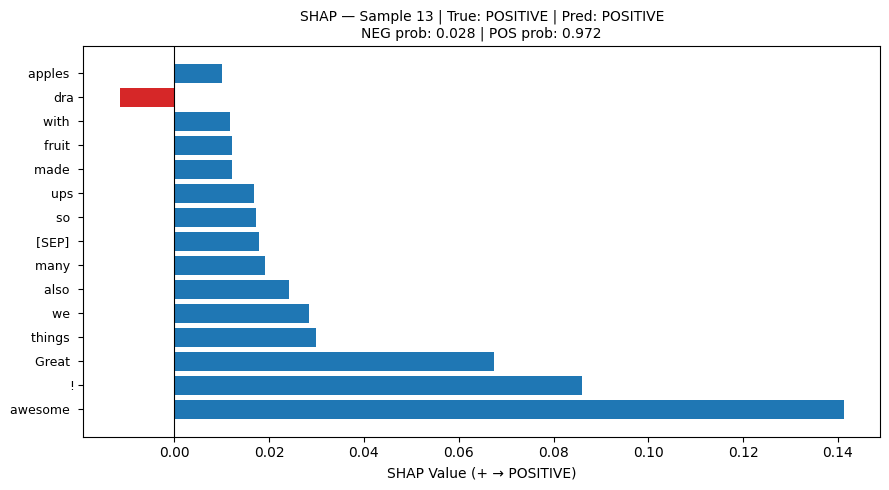

[14/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 2.3s


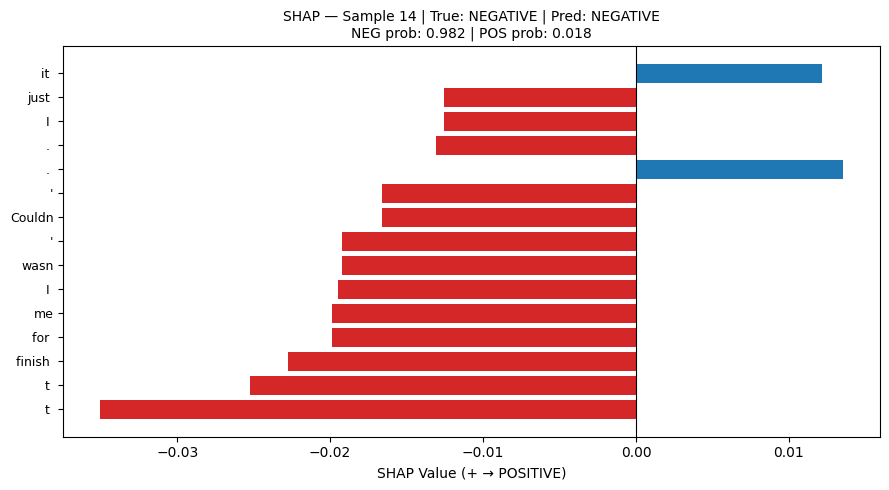

[15/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 1.8s


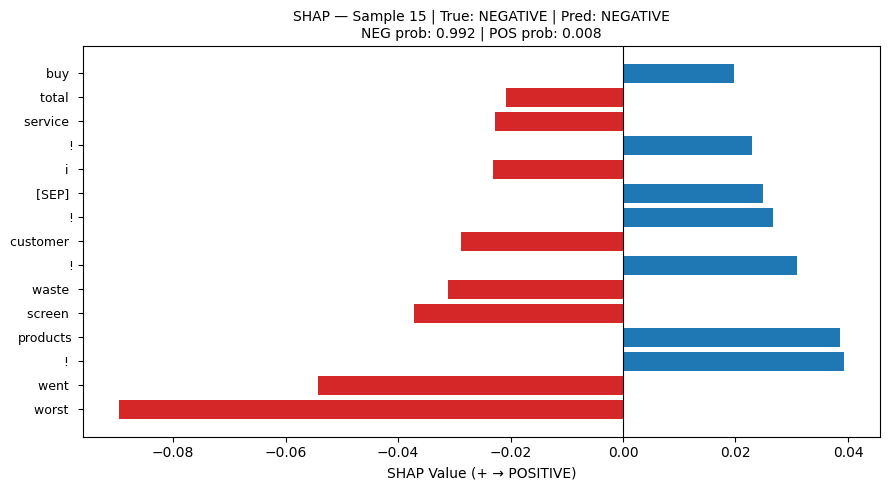

[16/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 2.3s


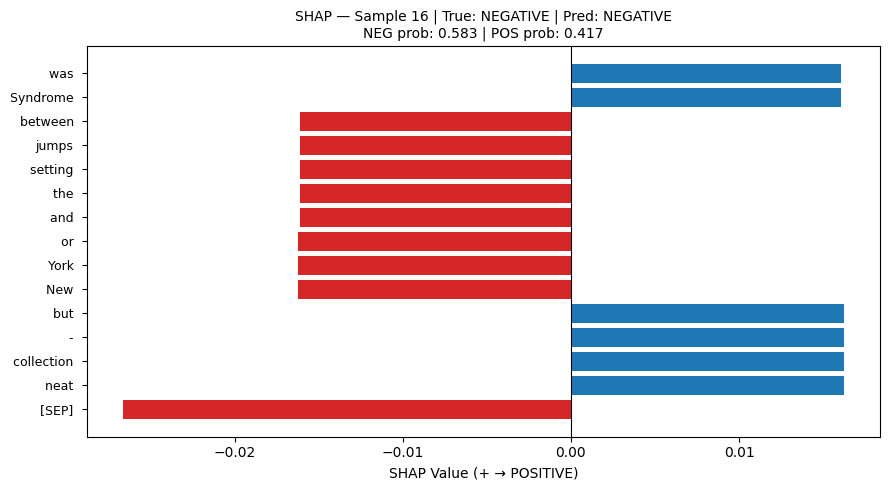

[17/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 1.7s


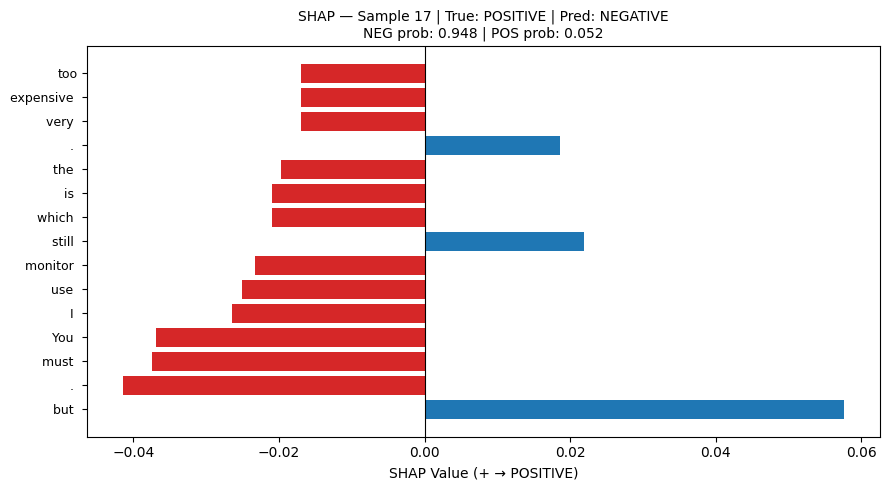

[18/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.8s


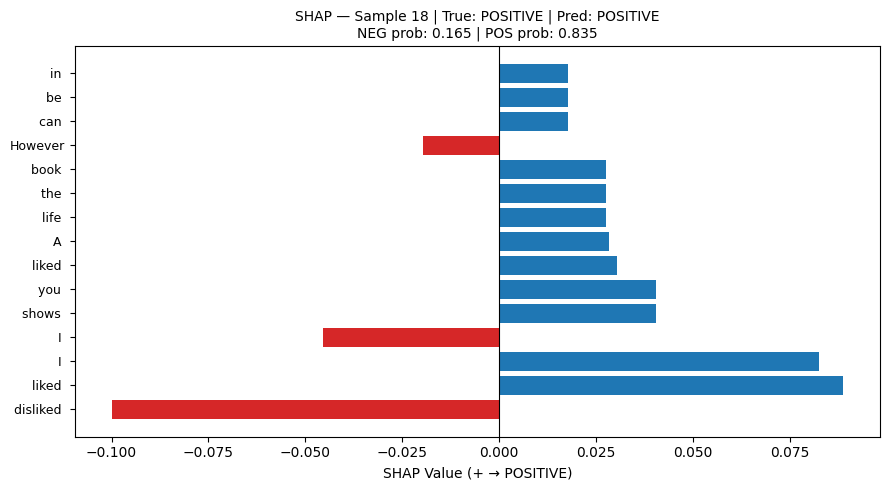

[19/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 1.9s


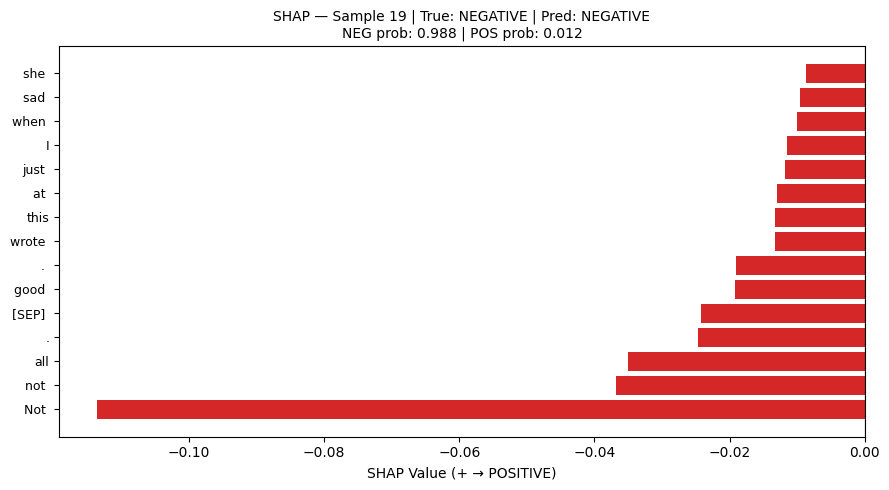

[20/25] True: POSITIVE | Pred: POSITIVE | ✓ | 2.3s


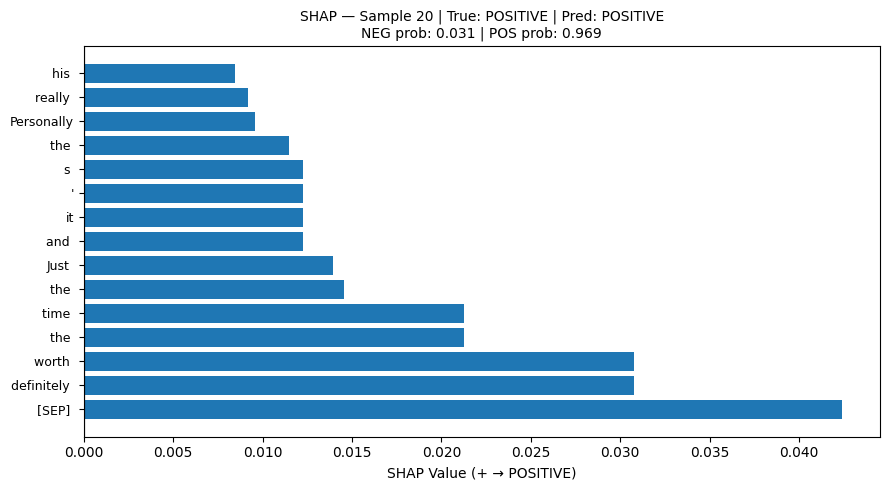

[21/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.8s


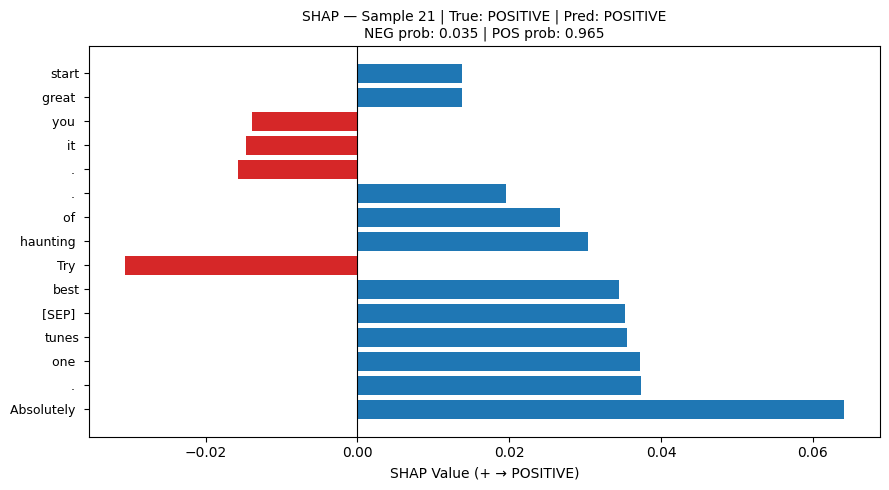

[22/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.8s


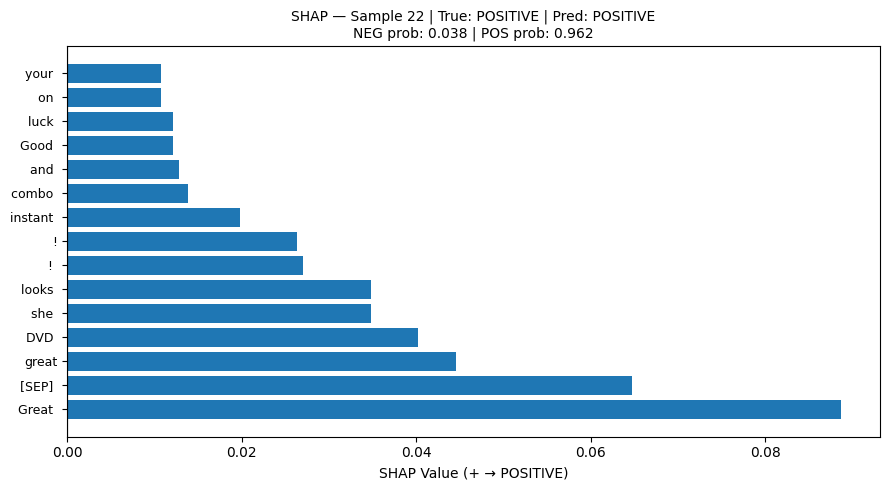

[23/25] True: POSITIVE | Pred: POSITIVE | ✓ | 1.6s


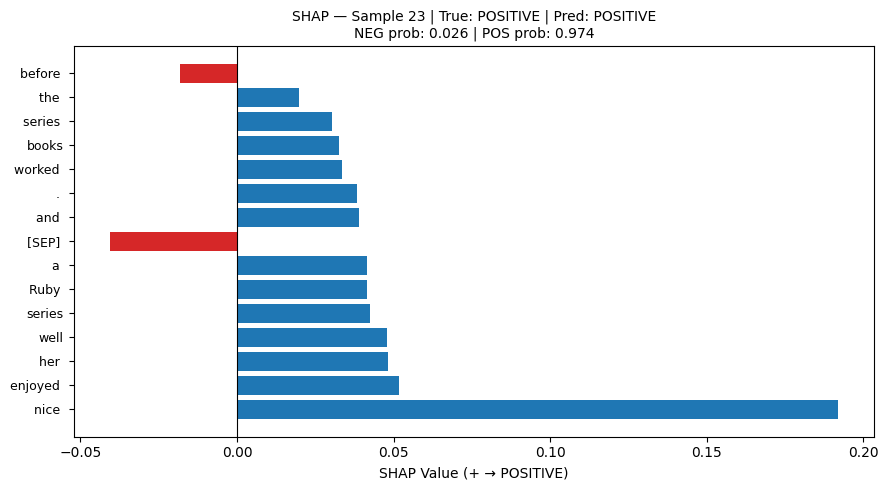

[24/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 1.6s


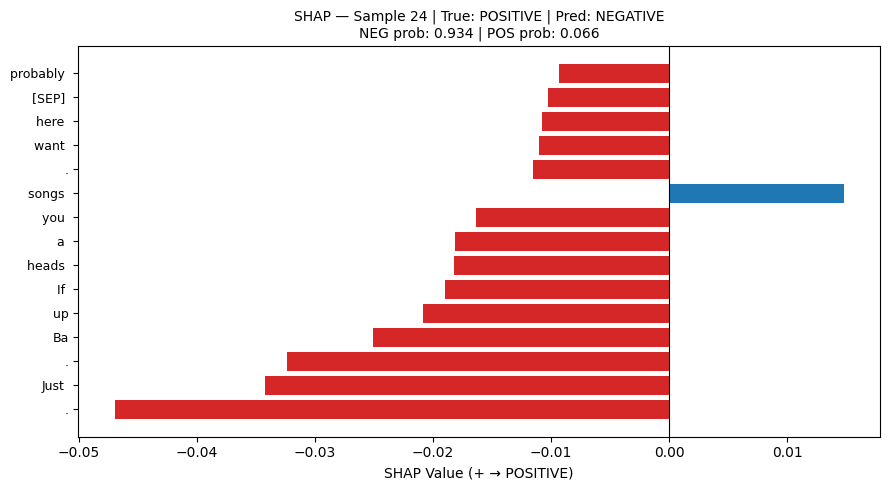

[25/25] True: POSITIVE | Pred: POSITIVE | ✓ | 2.4s


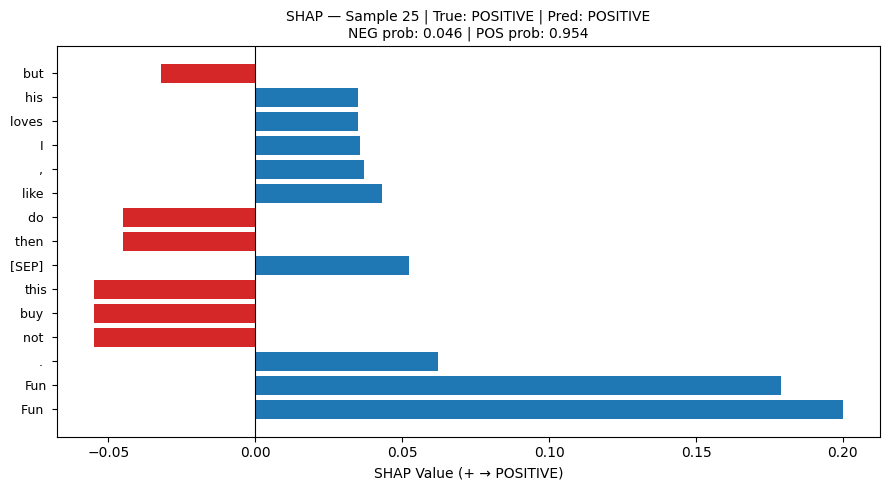


SHAP summary → ./results/shap_outputs/shap_summary.csv
Accuracy: 21/25
Avg runtime: 2.35s


In [17]:

os.makedirs("./results/shap_outputs", exist_ok=True)
shap_records = []

for i, (text, true_label) in enumerate(zip(explain_texts, explain_labels)):
    t0          = time.time()
    shap_values = explainer([text])
    elapsed     = time.time() - t0

    pred_arr = predict_proba([text])[0]
    pred_cls = int(np.argmax(pred_arr))
    pred_lbl = "POSITIVE" if pred_cls == 1 else "NEGATIVE"
    true_lbl = "POSITIVE" if true_label == 1 else "NEGATIVE"
    correct  = pred_cls == true_label

    print(f"[{i+1:02d}/{N_EXPLAIN}] True: {true_lbl} | Pred: {pred_lbl} | {'✓' if correct else '✗'} | {elapsed:.1f}s")

    # Bar chart of top-15 tokens
    vals   = shap_values.values[0, :, 1]
    toks   = list(shap_values.data[0])
    pairs  = sorted(zip(vals, toks), key=lambda x: abs(x[0]), reverse=True)[:15]
    vals_s, toks_s = zip(*pairs)
    colors = ["#d62728" if v < 0 else "#1f77b4" for v in vals_s]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(len(toks_s)), vals_s, color=colors)
    ax.set_yticks(range(len(toks_s)))
    ax.set_yticklabels(toks_s, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP Value (+ → POSITIVE)")
    ax.set_title(f"SHAP — Sample {i+1} | True: {true_lbl} | Pred: {pred_lbl}\n"
                 f"NEG prob: {pred_arr[0]:.3f} | POS prob: {pred_arr[1]:.3f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"./results/shap_outputs/shap_sample_{i+1:02d}.png", dpi=120, bbox_inches="tight")
    plt.show()

    shap_records.append({
        "sample_id":    i + 1,
        "text_snippet": text[:120],
        "true_label":   true_lbl,
        "pred_label":   pred_lbl,
        "correct":      correct,
        "neg_prob":     round(float(pred_arr[0]), 4),
        "pos_prob":     round(float(pred_arr[1]), 4),
        "runtime_s":    round(elapsed, 2),
    })

csv_path = "./results/shap_outputs/shap_summary.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=shap_records[0].keys())
    writer.writeheader()
    writer.writerows(shap_records)
print(f"\nSHAP summary → {csv_path}")
print(f"Accuracy: {sum(r['correct'] for r in shap_records)}/{N_EXPLAIN}")
print(f"Avg runtime: {np.mean([r['runtime_s'] for r in shap_records]):.2f}s")

## 9. LIME Explainability
Using **LimeTextExplainer** with 1,000 perturbations per sample.  
Generating explanations for **25 test samples** (same inputs as SHAP for fair comparison).


In [49]:
import torch, gc

# Clear Python garbage
gc.collect()

# Free GPU memory
torch.cuda.empty_cache()

# Optional: see memory stats after clearing
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
print(f"Reserved:  {torch.cuda.memory_reserved()  / 1024**2:.1f} MB")



Allocated: 9080.8 MB
Reserved:  12776.0 MB


In [50]:
import torch
import numpy as np
from transformers import BertForSequenceClassification, BertTokenizerFast

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and tokenizer
model = BertForSequenceClassification.from_pretrained("./results/bert_amazon_polarity")
tokenizer = BertTokenizerFast.from_pretrained("./results/bert_amazon_polarity")
model.to(device)
model.eval()
print("Model and tokenizer loaded!")

Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer loaded!


[01/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 4.4s


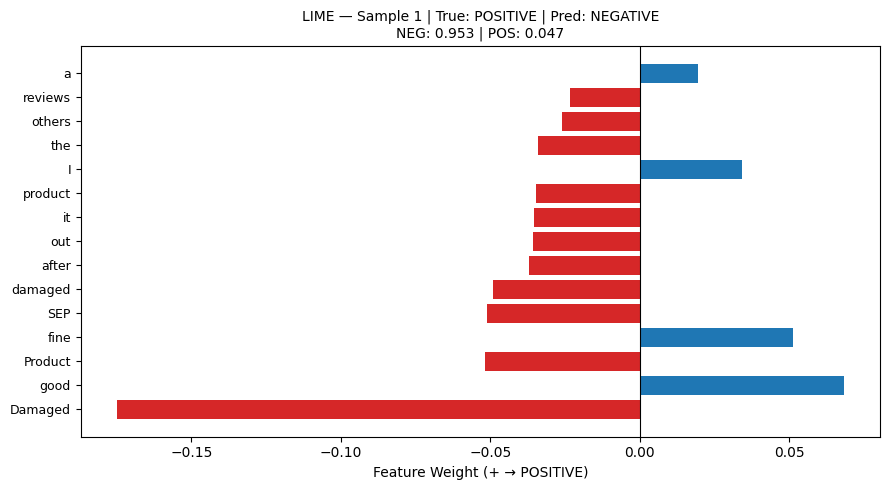

[02/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.8s


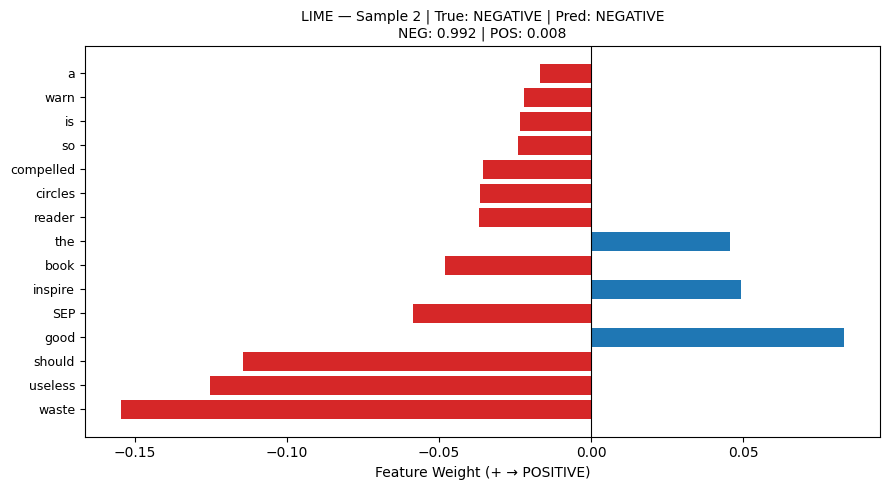

[03/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.6s


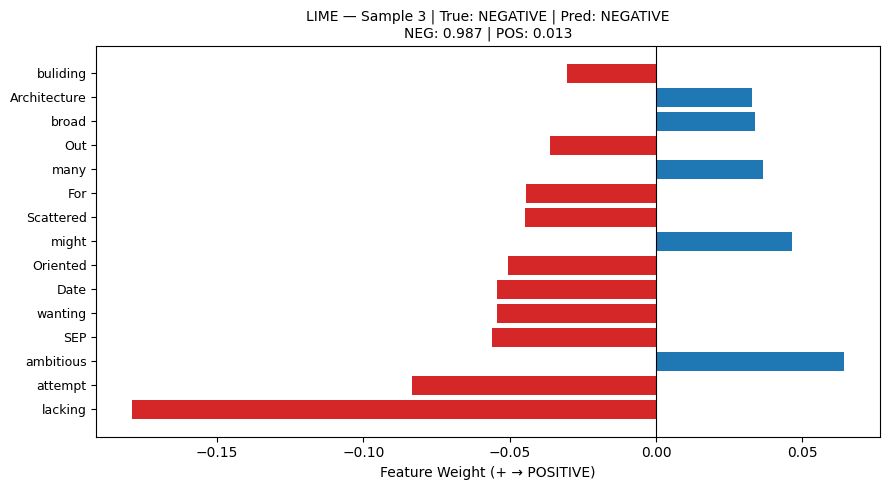

[04/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.9s


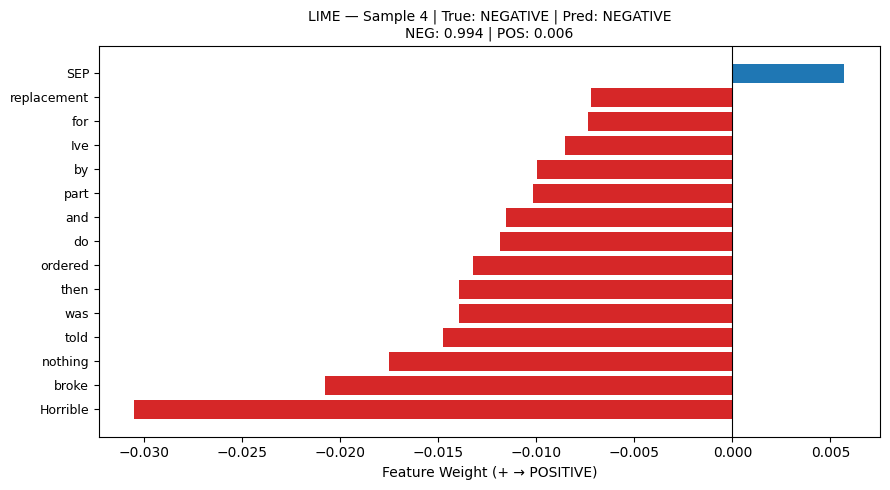

[05/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.7s


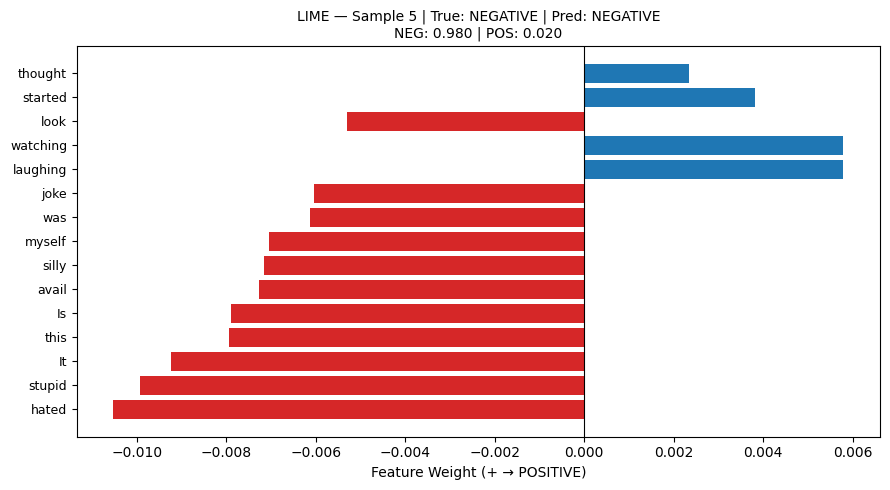

[06/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.7s


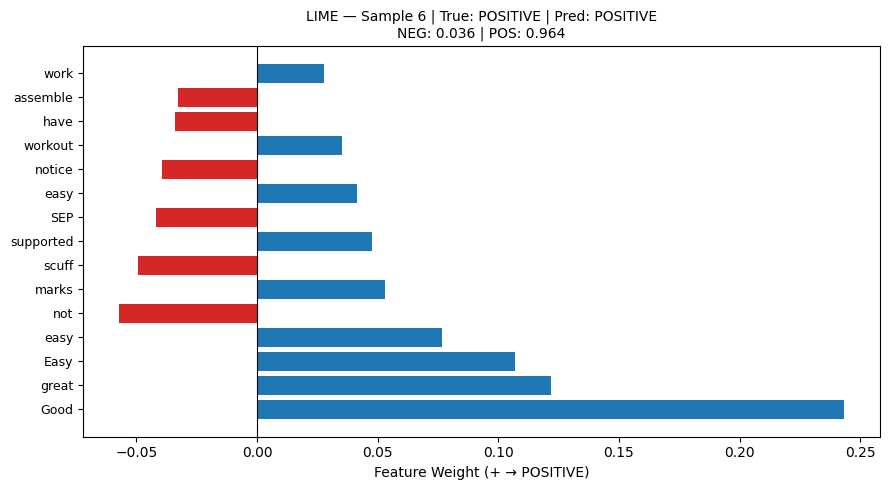

[07/25] True: POSITIVE | Pred: POSITIVE | ✓ | 4.0s


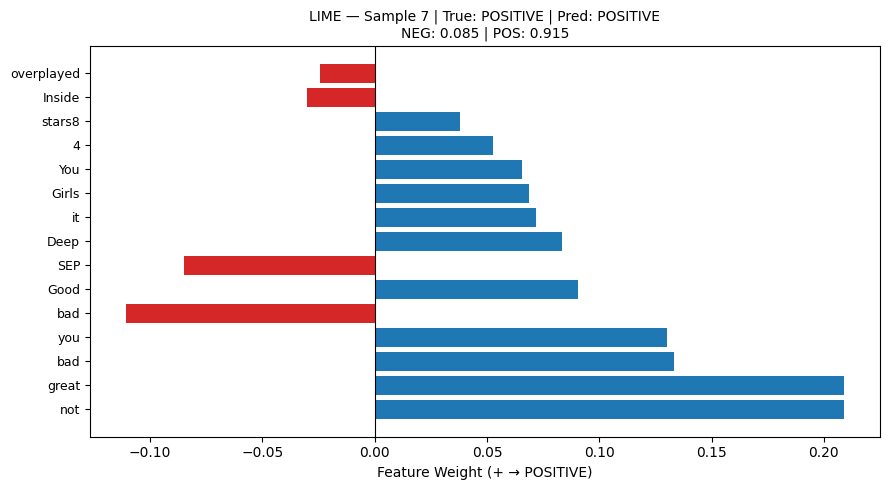

[08/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.8s


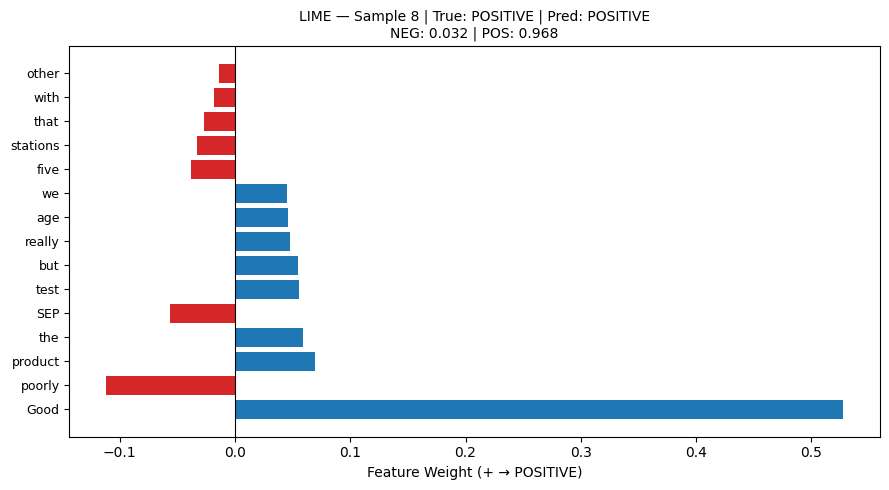

[09/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 3.9s


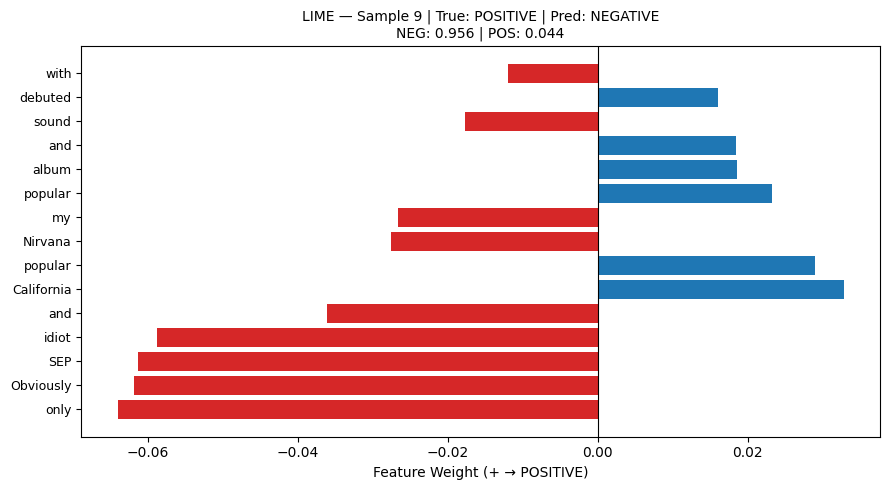

[10/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.3s


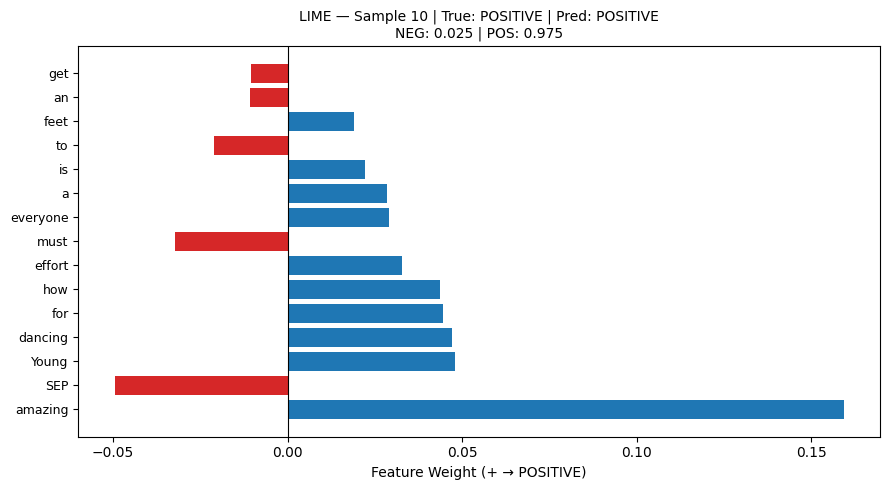

[11/25] True: NEGATIVE | Pred: POSITIVE | ✗ | 3.8s


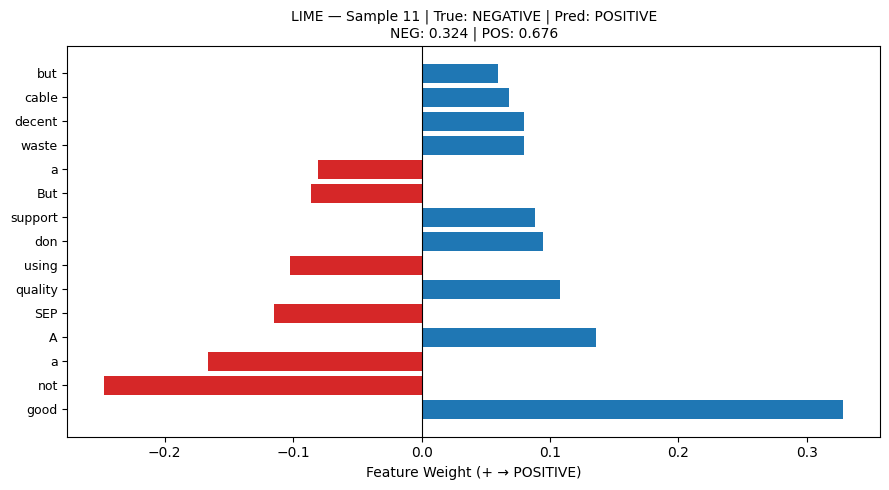

[12/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 4.1s


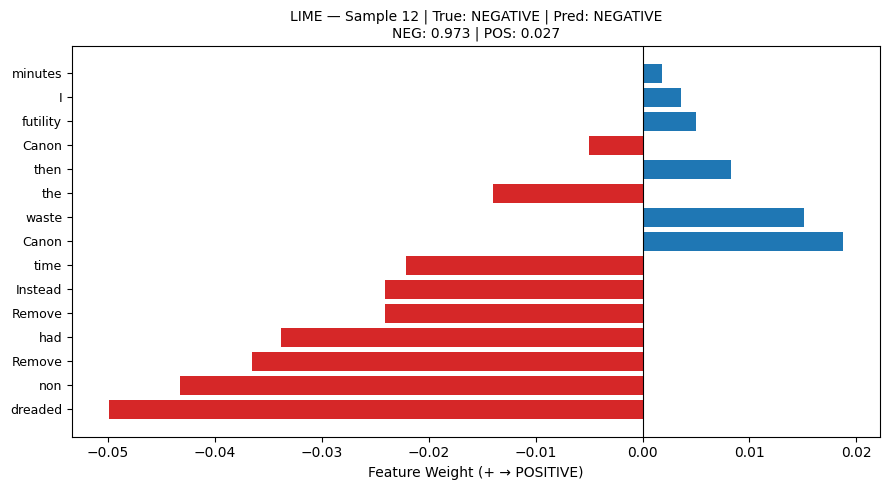

[13/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.5s


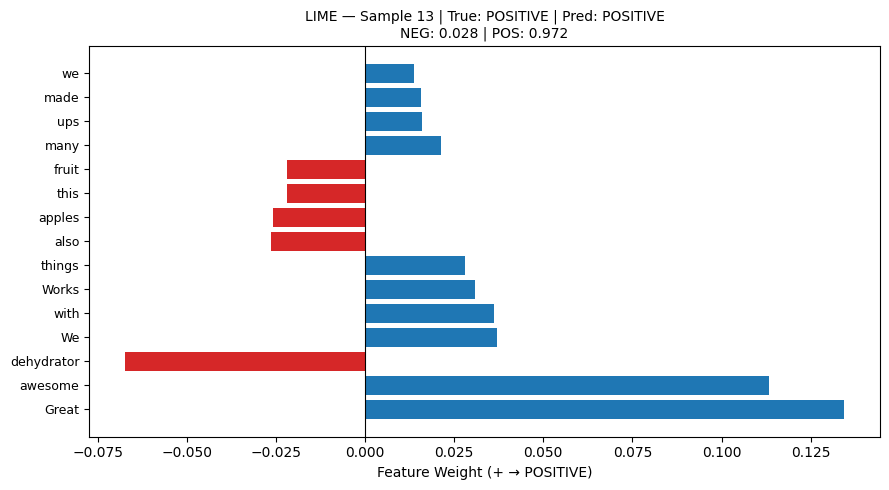

[14/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.9s


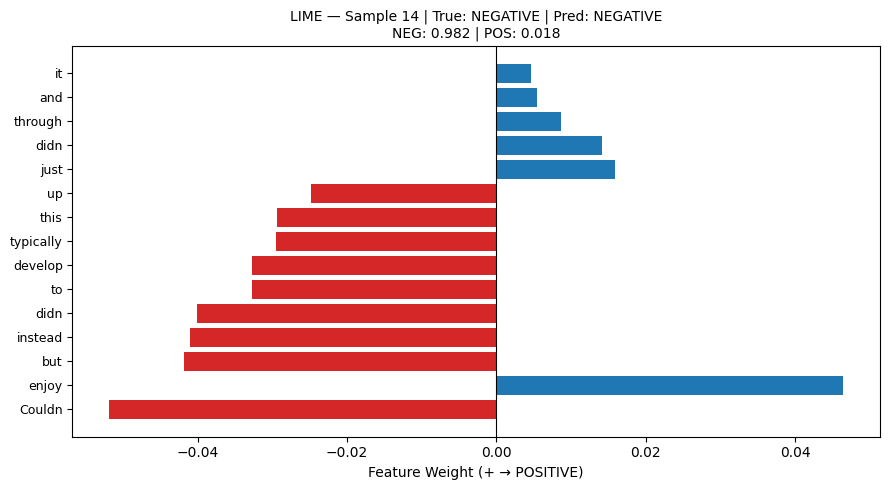

[15/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.8s


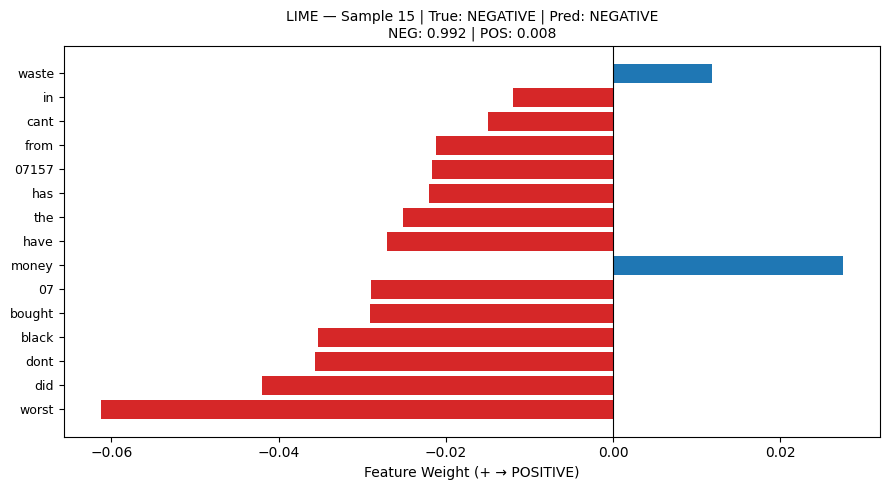

[16/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 4.0s


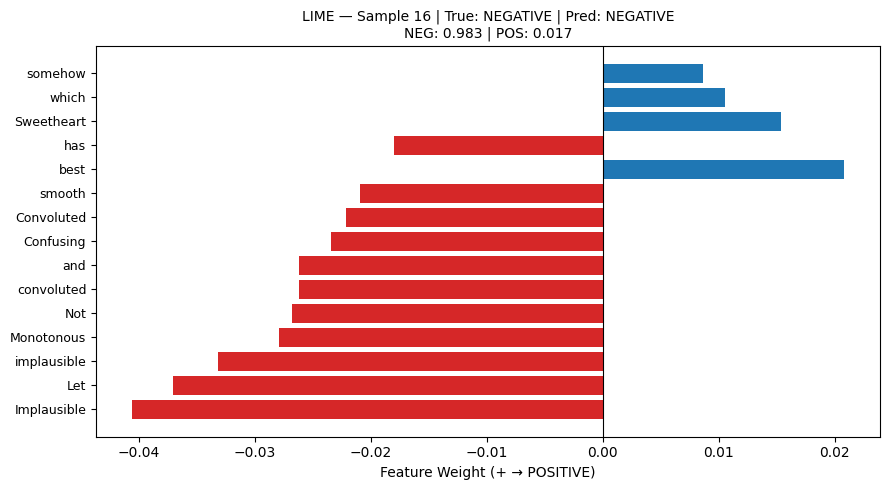

[17/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 3.8s


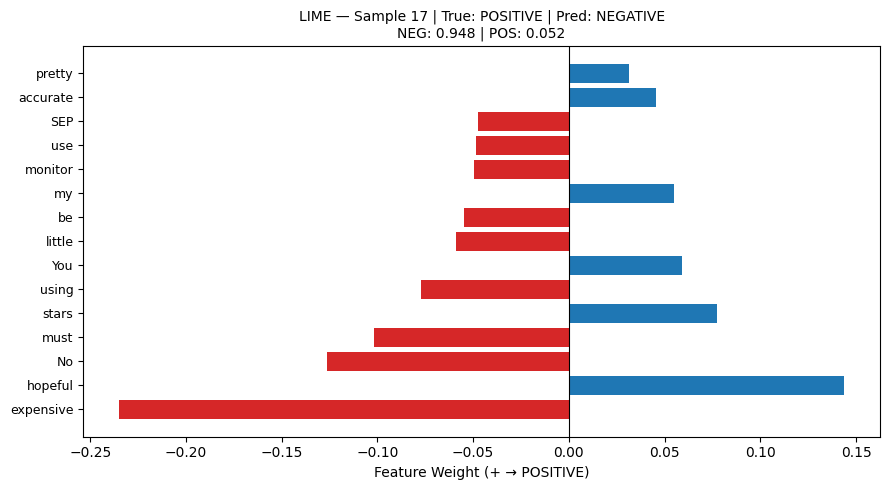

[18/25] True: POSITIVE | Pred: POSITIVE | ✓ | 3.9s


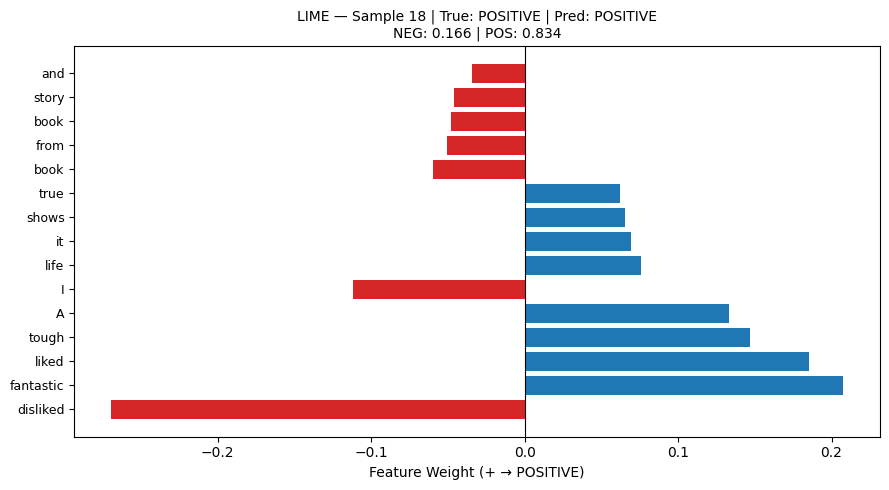

[19/25] True: NEGATIVE | Pred: NEGATIVE | ✓ | 3.8s


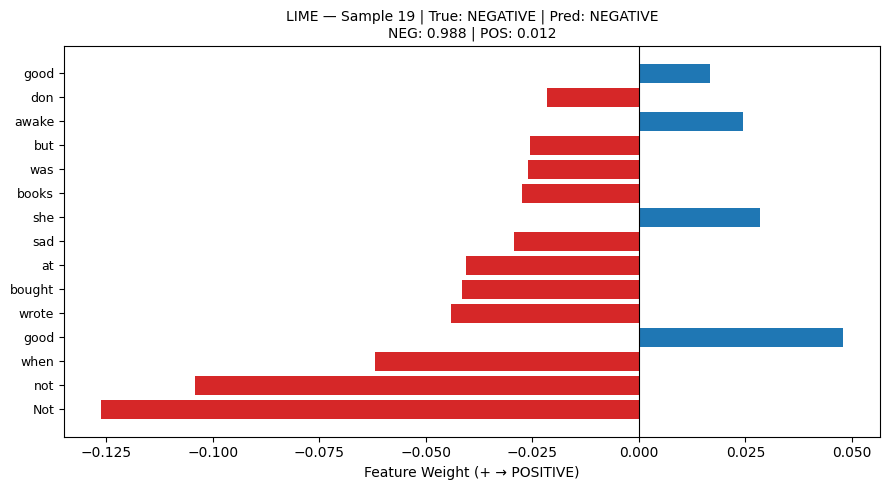

[20/25] True: POSITIVE | Pred: POSITIVE | ✓ | 4.0s


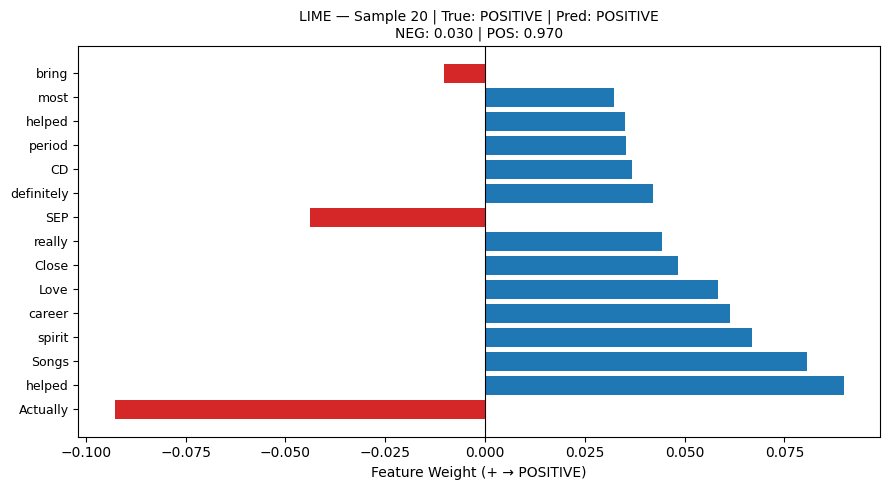

[21/25] True: POSITIVE | Pred: POSITIVE | ✓ | 4.0s


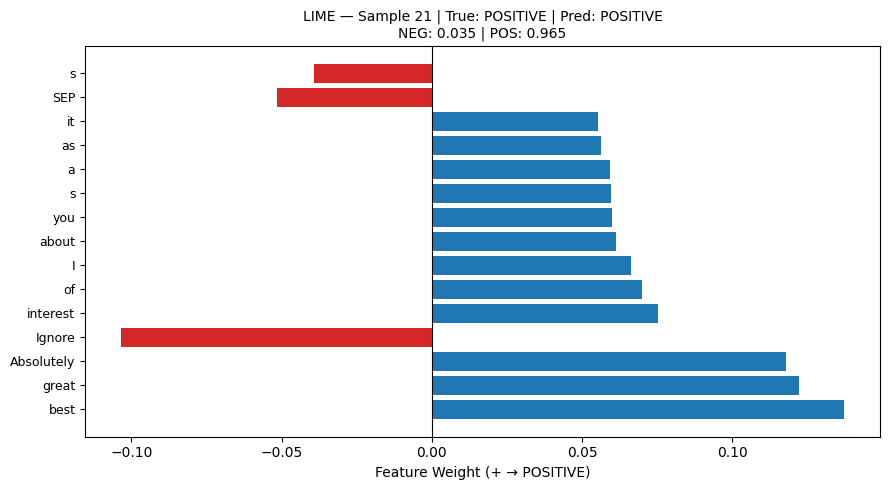

[22/25] True: POSITIVE | Pred: POSITIVE | ✓ | 4.0s


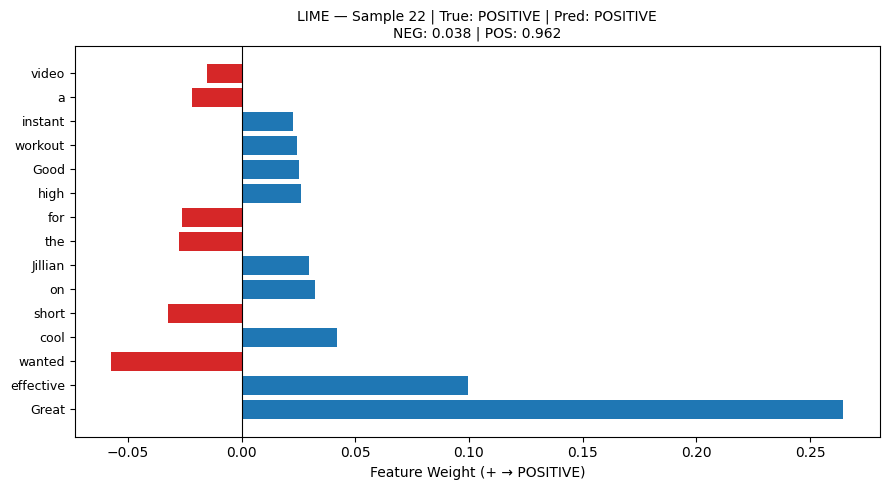

[23/25] True: POSITIVE | Pred: POSITIVE | ✓ | 2.9s


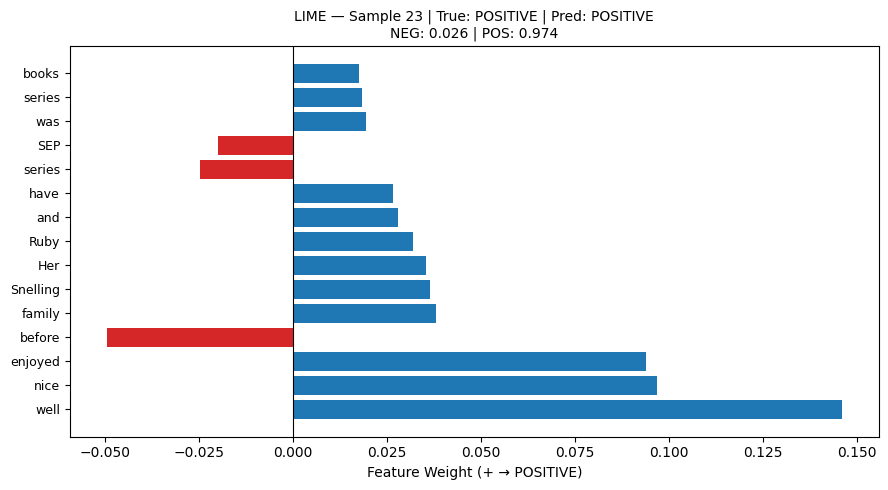

[24/25] True: POSITIVE | Pred: NEGATIVE | ✗ | 4.0s


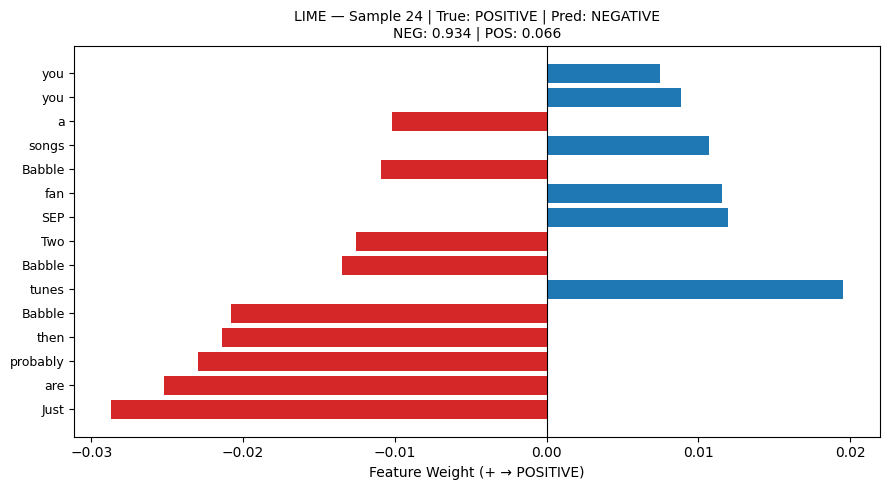

[25/25] True: POSITIVE | Pred: POSITIVE | ✓ | 4.0s


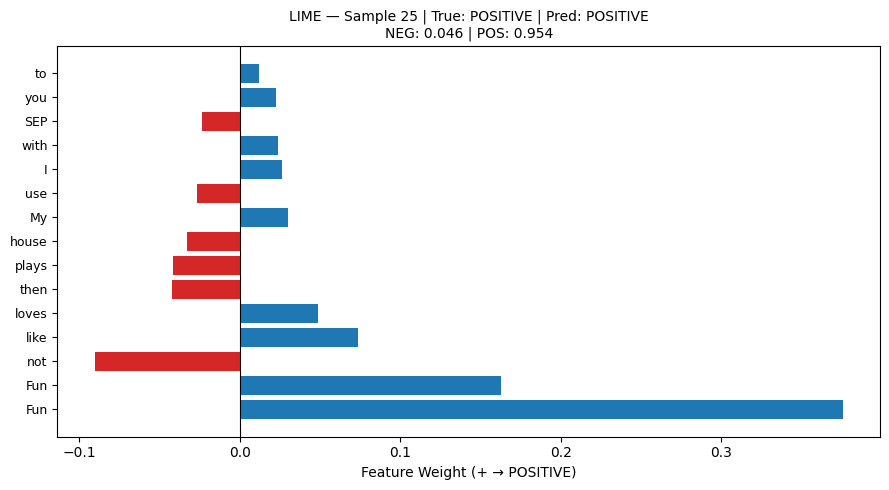


LIME summary → ./results/lime_outputs/lime_summary.csv
Accuracy : 20/25
Avg runtime: 3.82s
Avg stability (Jaccard): 0.335


In [28]:
N_EXPLAIN   = 25
N_SAMPLES   = 500      # ← reduced from 1000 (halves GPU calls)
CLASS_NAMES = ["NEGATIVE", "POSITIVE"]

lime_explainer = LimeTextExplainer(class_names=CLASS_NAMES, random_state=SEED, bow=False)
os.makedirs("./results/lime_outputs", exist_ok=True)

lime_records   = []
stability_runs = {}

# ── memory-efficient predict_proba with smaller batch size ────────────────────
BATCH_SIZE = 16   # ← process 16 texts at a time instead of all at once

def predict_proba_batched(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    texts = [str(t) for t in texts]

    all_probs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,   # ← reduced from 512 (big memory saving)
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

        # free batch tensors immediately
        del encoded, logits
        torch.cuda.empty_cache()

    return np.vstack(all_probs)

# ── main loop ─────────────────────────────────────────────────────────────────
for i, (text, true_label) in enumerate(zip(explain_texts, explain_labels)):
    # free memory before each sample
    gc.collect()
    torch.cuda.empty_cache()

    t0  = time.time()
    exp = lime_explainer.explain_instance(
        text, predict_proba_batched,
        num_features=15,
        num_samples=N_SAMPLES,
        labels=[0, 1]
    )
    elapsed = time.time() - t0

    pred_proba = predict_proba_batched([text])[0]
    pred_cls   = int(np.argmax(pred_proba))
    pred_lbl   = CLASS_NAMES[pred_cls]
    true_lbl   = CLASS_NAMES[true_label]
    correct    = pred_cls == true_label

    print(f"[{i+1:02d}/{N_EXPLAIN}] True: {true_lbl} | Pred: {pred_lbl} | {'✓' if correct else '✗'} | {elapsed:.1f}s")

    feature_weights = exp.as_list(label=1)
    words   = [fw[0] for fw in feature_weights]
    weights = [fw[1] for fw in feature_weights]
    colors  = ["#d62728" if w < 0 else "#1f77b4" for w in weights]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(len(words)), weights, color=colors)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Feature Weight (+ → POSITIVE)")
    ax.set_title(f"LIME — Sample {i+1} | True: {true_lbl} | Pred: {pred_lbl}\n"
                 f"NEG: {pred_proba[0]:.3f} | POS: {pred_proba[1]:.3f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"./results/lime_outputs/lime_sample_{i+1:02d}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)   # ← explicitly close figure to free matplotlib memory

    # Stability: run twice on first 5 samples
    if i < 5:
        exp2 = lime_explainer.explain_instance(
            text, predict_proba_batched, num_features=15, num_samples=N_SAMPLES, labels=[0, 1]
        )
        w1 = set(fw[0] for fw in exp.as_list(label=1))
        w2 = set(fw[0] for fw in exp2.as_list(label=1))
        stability_runs[i] = round(len(w1 & w2) / len(w1 | w2) if (w1 | w2) else 1.0, 3)

    lime_records.append({
        "sample_id":    i + 1,
        "text_snippet": text[:120],
        "true_label":   true_lbl,
        "pred_label":   pred_lbl,
        "correct":      correct,
        "neg_prob":     round(float(pred_proba[0]), 4),
        "pos_prob":     round(float(pred_proba[1]), 4),
        "runtime_s":    round(elapsed, 2),
        "top_pos_word": words[0] if words else "",
    })

csv_path = "./results/lime_outputs/lime_summary.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=lime_records[0].keys())
    writer.writeheader()
    writer.writerows(lime_records)

print(f"\nLIME summary → {csv_path}")
print(f"Accuracy : {sum(r['correct'] for r in lime_records)}/{N_EXPLAIN}")
print(f"Avg runtime: {np.mean([r['runtime_s'] for r in lime_records]):.2f}s")
print(f"Avg stability (Jaccard): {np.mean(list(stability_runs.values())):.3f}")

## 10. Comparative Analysis: SHAP vs LIME
Evaluating **faithfulness** (confidence drop when top-5 tokens are masked),  
**stability** (Jaccard overlap across two independent runs), and **runtime**.


In [34]:
N_CMP    = 5      # samples for comparison
LIME_NS  = 50     # LIME perturbations

os.makedirs("./results/comparison", exist_ok=True)
cmp_texts = texts_all[:N_CMP]

cmp_masker   = shap.maskers.Text(shap_tokenizer)
cmp_shap_exp = shap.Explainer(predict_proba, cmp_masker, output_names=["NEGATIVE", "POSITIVE"])
cmp_lime_exp = LimeTextExplainer(class_names=CLASS_NAMES, random_state=SEED, bow=False)

records = []

for i, text in enumerate(cmp_texts):
    print(f"Comparing sample {i+1}/{N_CMP}...")
    orig_prob = predict_proba([text])[0]
    pred_cls  = int(np.argmax(orig_prob))

    # ── SHAP ──────────────────────────────────────────────────────────
    t0 = time.time()
    sv = cmp_shap_exp([text])
    shap_rt = time.time() - t0

    shap_vals  = sv.values[0, :, pred_cls]
    shap_toks  = list(sv.data[0])
    shap_top5  = [t for _, t in sorted(zip(np.abs(shap_vals), shap_toks), reverse=True)[:5]]
    masked_s   = " ".join("[MASK]" if w in shap_top5 else w for w in text.split())
    shap_faith = orig_prob[pred_cls] - predict_proba([masked_s])[0][pred_cls]

    sv2        = cmp_shap_exp([text])
    shap_vals2 = sv2.values[0, :, pred_cls]
    shap_toks2 = list(sv2.data[0])
    shap_top5_2= [t for _, t in sorted(zip(np.abs(shap_vals2), shap_toks2), reverse=True)[:5]]
    s1, s2     = set(shap_top5), set(shap_top5_2)
    shap_stab  = len(s1 & s2) / len(s1 | s2) if (s1 | s2) else 1.0

    # ── LIME ──────────────────────────────────────────────────────────
    t0 = time.time()
    le = cmp_lime_exp.explain_instance(text, predict_proba, num_features=5,
                                        num_samples=LIME_NS, labels=[0, 1])
    lime_rt    = time.time() - t0
    lime_top5  = [fw[0] for fw in le.as_list(label=pred_cls)][:5]
    masked_l   = " ".join("[MASK]" if w in lime_top5 else w for w in text.split())
    lime_faith = orig_prob[pred_cls] - predict_proba([masked_l])[0][pred_cls]

    le2        = cmp_lime_exp.explain_instance(text, predict_proba, num_features=5,
                                                num_samples=LIME_NS, labels=[0, 1])
    lime_top5_2= [fw[0] for fw in le2.as_list(label=pred_cls)][:5]
    l1, l2     = set(lime_top5), set(lime_top5_2)
    lime_stab  = len(l1 & l2) / len(l1 | l2) if (l1 | l2) else 1.0

    records.append({
        "sample_id": i+1,
        "shap_rt":   round(shap_rt, 2),  "lime_rt":   round(lime_rt, 2),
        "shap_faith":round(float(shap_faith), 4), "lime_faith":round(float(lime_faith), 4),
        "shap_stab": round(float(shap_stab), 3),  "lime_stab": round(float(lime_stab), 3),
    })

csv_path = "./results/comparison/shap_lime_comparison.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=records[0].keys())
    writer.writeheader()
    writer.writerows(records)
print(f"Saved: {csv_path}")

Comparing sample 1/5...
Comparing sample 2/5...
Comparing sample 3/5...
Comparing sample 4/5...
Comparing sample 5/5...
Saved: ./results/comparison/shap_lime_comparison.csv


Metric                                 SHAP       LIME
-------------------------------------------------------
Avg Runtime (s)                        3.37       3.11
Avg Faithfulness ↑                   0.0000     0.0841
Avg Stability (Jaccard) ↑             1.000      0.047


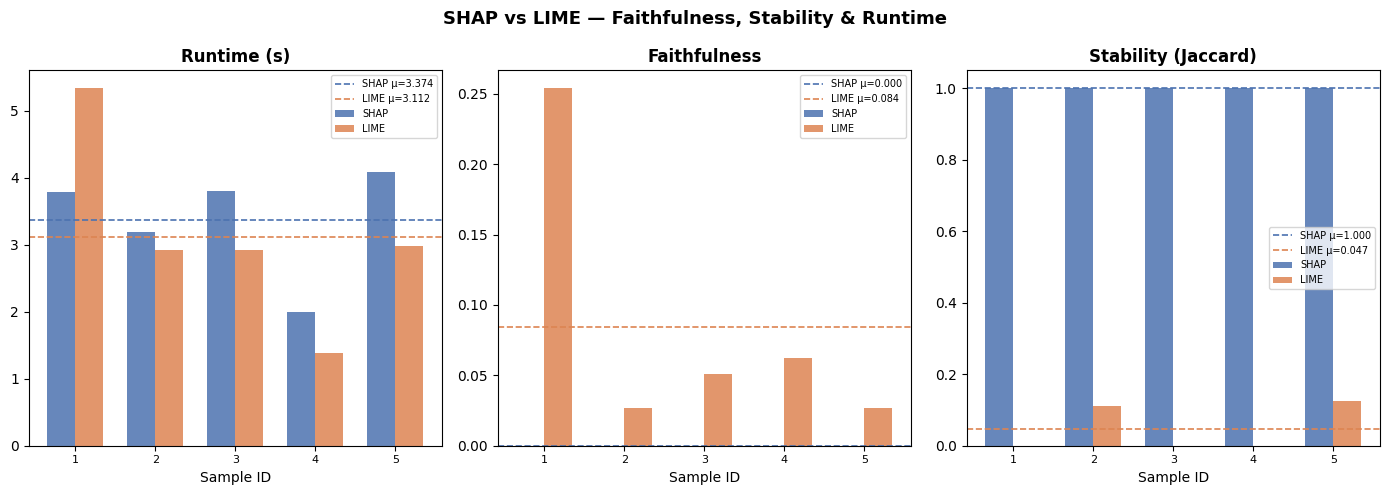

In [35]:
# ── Summary table ─────────────────────────────────────────────────────
shap_rts    = [r["shap_rt"]    for r in records]
lime_rts    = [r["lime_rt"]    for r in records]
shap_faiths = [r["shap_faith"] for r in records]
lime_faiths = [r["lime_faith"] for r in records]
shap_stabs  = [r["shap_stab"]  for r in records]
lime_stabs  = [r["lime_stab"]  for r in records]

print(f"{'Metric':<32} {'SHAP':>10} {'LIME':>10}")
print("-" * 55)
print(f"{'Avg Runtime (s)':<32} {np.mean(shap_rts):>10.2f} {np.mean(lime_rts):>10.2f}")
print(f"{'Avg Faithfulness ↑':<32} {np.mean(shap_faiths):>10.4f} {np.mean(lime_faiths):>10.4f}")
print(f"{'Avg Stability (Jaccard) ↑':<32} {np.mean(shap_stabs):>10.3f} {np.mean(lime_stabs):>10.3f}")

# ── Grouped bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_data = [
    ("Runtime (s)",          shap_rts,    lime_rts),
    ("Faithfulness",         shap_faiths, lime_faiths),
    ("Stability (Jaccard)",  shap_stabs,  lime_stabs),
]
for ax, (title, sv, lv) in zip(axes, metrics_data):
    x = np.arange(N_CMP)
    w = 0.35
    ax.bar(x-w/2, sv, w, label="SHAP", color="#4C72B0", alpha=0.85)
    ax.bar(x+w/2, lv, w, label="LIME", color="#DD8452", alpha=0.85)
    ax.axhline(np.mean(sv), color="#4C72B0", linestyle="--", linewidth=1.2,
               label=f"SHAP μ={np.mean(sv):.3f}")
    ax.axhline(np.mean(lv), color="#DD8452", linestyle="--", linewidth=1.2,
               label=f"LIME μ={np.mean(lv):.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Sample ID")
    ax.set_xticks(x)
    ax.set_xticklabels([str(r["sample_id"]) for r in records], fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("SHAP vs LIME — Faithfulness, Stability & Runtime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./results/comparison/shap_lime_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Error Analysis
Identifying misclassified samples from 300 test examples.  
LIME explanations are applied to the **top 10 most confident errors** to understand failure modes.


In [39]:
N_TEST = 300
np.random.seed(SEED)
err_test_split = dataset["test"].shuffle(seed=SEED).select(range(N_TEST))
err_texts  = [t + " [SEP] " + c for t, c in zip(err_test_split["title"], err_test_split["content"])]
err_labels = list(err_test_split["label"])
CLASS      = ["NEGATIVE", "POSITIVE"]

print("Running inference on 300 samples...")
all_probs = predict_proba(err_texts)
all_preds = all_probs.argmax(axis=1)

errors, corrects = [], []
for i, (text, true, pred, prob) in enumerate(zip(err_texts, err_labels, all_preds, all_probs)):
    entry = {"idx": i, "text": text, "true_label": CLASS[true],
             "pred_label": CLASS[pred], "confidence": round(float(prob[pred]), 4),
             "correct": true == pred}
    (errors if true != pred else corrects).append(entry)

fn = sum(1 for e in errors if e["true_label"] == "POSITIVE")
fp = sum(1 for e in errors if e["true_label"] == "NEGATIVE")
print(f"Total: {N_TEST} | Correct: {len(corrects)} | Errors: {len(errors)}")
print(f"Error rate: {len(errors)/N_TEST*100:.1f}% | FN: {fn} | FP: {fp}")

Running inference on 300 samples...
Total: 300 | Correct: 280 | Errors: 20
Error rate: 6.7% | FN: 14 | FP: 6


In [51]:
os.makedirs("./results/error_analysis", exist_ok=True)
err_lime_exp = LimeTextExplainer(class_names=CLASS, random_state=SEED, bow=False)
top_errors   = sorted(errors, key=lambda x: x["confidence"], reverse=True)[:10]
error_records = []

for j, err in enumerate(top_errors):
    pred_cls     = CLASS.index(err["pred_label"])
    exp          = err_lime_exp.explain_instance(err["text"], predict_proba,
                                                  num_features=10, num_samples=500, labels=[0, 1])
    feat_weights = exp.as_list(label=pred_cls)
    words   = [fw[0] for fw in feat_weights]
    weights = [fw[1] for fw in feat_weights]
    colors  = ["#d62728" if w < 0 else "#1f77b4" for w in weights]

    text_lower = err["text"].lower()
    if "not" in text_lower or "don't" in text_lower or "doesn't" in text_lower:
        cause = "Negation failure — 'not' partially suppressed"
    elif len(err["text"].split()) > 100:
        cause = "Long text truncation — key sentiment beyond token 128"
    elif err["confidence"] > 0.85:
        cause = "High-confidence error — likely sarcasm / domain-specific language"
    else:
        cause = "Ambiguous / mixed-sentiment text"

    print(f"[{j+1:02d}] True: {err['true_label']} → Pred: {err['pred_label']} "
          f"(conf={err['confidence']:.3f}) | {cause}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    ax.barh(range(len(words)), weights, color=colors)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Feature Weight")
    ax.set_title(f"LIME — Error {j+1} | True: {err['true_label']} | Pred: {err['pred_label']}", fontsize=9)

    ax2 = axes[1]
    ax2.axis("off")
    snippet = err["text"][:350].replace("[SEP]", "\n[SEP]")
    ax2.text(0.02, 0.95, "Text Snippet:", fontsize=9, fontweight="bold", va="top")
    ax2.text(0.02, 0.87, snippet, fontsize=7.5, va="top",
             bbox=dict(boxstyle="round", facecolor="#f8f8f8", edgecolor="#cccccc"))
    ax2.text(0.02, 0.18, f"Confidence: {err['confidence']:.3f}", fontsize=8)
    ax2.text(0.02, 0.11, "Likely cause:", fontsize=8, fontweight="bold")
    ax2.text(0.02, 0.05, cause, fontsize=8, color="#cc0000")

    plt.suptitle(f"Error Analysis — Sample {j+1}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"./results/error_analysis/error_{j+1:02d}.png", dpi=130, bbox_inches="tight")
    plt.show()

    error_records.append({
        "rank": j+1, "true_label": err["true_label"], "pred_label": err["pred_label"],
        "confidence": err["confidence"], "cause": cause,
        "top_words": ", ".join(words[:5]), "text": err["text"][:150],
    })

csv_path = "./results/error_analysis/error_records.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=error_records[0].keys())
    writer.writeheader()
    writer.writerows(error_records)
print(f"\nError records → {csv_path}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.48 GiB. GPU 0 has a total capacity of 14.56 GiB of which 475.81 MiB is free. Including non-PyTorch memory, this process has 14.10 GiB memory in use. Of the allocated memory 11.53 GiB is allocated by PyTorch, and 2.43 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# ── Confidence distribution: errors vs correct ────────────────────────
err_confs  = [e["confidence"] for e in errors]
corr_confs = [c["confidence"] for c in corrects]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(corr_confs, bins=20, alpha=0.7, label="Correct", color="#2ca02c")
axes[0].hist(err_confs,  bins=20, alpha=0.7, label="Errors",  color="#d62728")
axes[0].set_xlabel("Model Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("Confidence Distribution: Correct vs Errors")
axes[0].legend()

axes[1].bar(["False Negative\n(true POS → NEG)", "False Positive\n(true NEG → POS)"],
            [fn, fp], color=["#9467bd", "#8c564b"])
axes[1].set_ylabel("Count")
axes[1].set_title("Error Type Breakdown")

plt.tight_layout()
plt.savefig("./results/error_analysis/error_overview.png", dpi=150)
plt.show()
print("All analysis complete! Results saved in ./results/")